In [ ]:
--Healthcare Readmission Project--

In [ ]:
## Step 1: Project Setup
```
#healthcare-readmission-etl/
#│
#├── data/
#│   ├── raw/              # Original CSVs go here
#│   └── processed/        # Cleaned outputs
#├── src/
#│   ├── __init__.py
#│   ├── extract.py
#│   ├── transform.py
#│   ├── load.py
#│   └── etl_pipeline.py
#├── sql/
#│   └── schema.sql
#├── requirements.txt
#└── README.md
```

In [2]:
"""
extract.py
Handles loading raw data from CSV files into pandas DataFrames.
"""

import logging
from pathlib import Path

import pandas as pd

logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")
logger = logging.getLogger(__name__)

RAW_DATA_PATH = Path(r"C:\Users\oxdon\OneDrive\Documents\diabetic_data.csv")
MAPPING_PATH = Path(r"C:\Users\oxdon\OneDrive\Documents\IDS_mapping.csv")


def extract_diabetes_data(raw_data_path: str | Path = RAW_DATA_PATH) -> pd.DataFrame:
    """
    Extract raw diabetes dataset from CSV.

    Args:
        raw_data_path: Path to diabetic_data.csv

    Returns:
        Raw DataFrame
    """
    raw_data_path = Path(raw_data_path)

    if not raw_data_path.exists():
        raise FileNotFoundError(f"Dataset not found at {raw_data_path}")

    logger.info("Extracting data from %s", raw_data_path)
    df = pd.read_csv(raw_data_path)
    logger.info("Extracted %s rows and %s columns", f"{len(df):,}", len(df.columns))
    return df


def extract_id_mappings(mapping_path: str | Path = MAPPING_PATH) -> dict:
    """
    Extract ID mappings from CSV.

    Returns:
        Dictionary of mapping tables.
    """
    mapping_path = Path(mapping_path)

    if not mapping_path.exists():
        raise FileNotFoundError(f"Mapping file not found at {mapping_path}")

    logger.info("Extracting ID mappings from %s", mapping_path)

    df = pd.read_csv(mapping_path)

    mappings = {}
    for col in df.columns:
        if col.lower() != "description":
            mappings[col] = dict(zip(df[col], df["description"]))

    logger.info("Loaded %s mapping tables", len(mappings))
    return mappings


if __name__ == "__main__":
    df = extract_diabetes_data()
    mappings = extract_id_mappings()

    print(df.head())
    print(mappings.keys())

2026-05-06 17:47:08,829 - INFO - Extracting data from C:\Users\oxdon\OneDrive\Documents\diabetic_data.csv
2026-05-06 17:47:09,877 - INFO - Extracted 101,766 rows and 50 columns
2026-05-06 17:47:09,879 - INFO - Extracting ID mappings from C:\Users\oxdon\OneDrive\Documents\IDS_mapping.csv
2026-05-06 17:47:09,966 - INFO - Loaded 1 mapping tables


   encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)      ?   
1        149190     55629189        Caucasian  Female  [10-20)      ?   
2         64410     86047875  AfricanAmerican  Female  [20-30)      ?   
3        500364     82442376        Caucasian    Male  [30-40)      ?   
4         16680     42519267        Caucasian    Male  [40-50)      ?   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   
3                  1                         1                    7   
4                  1                         1                    7   

   time_in_hospital  ... citoglipton insulin  glyburide-metformin  \
0                 1  ...          No      No                   No

In [3]:
import os
print("Working from:", os.getcwd())

Working from: C:\Users\oxdon\HealthcareReadmissionProject\notebooks


In [4]:
import os
import logging
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')

# Logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Define paths (relative to notebook location)
PROJECT_ROOT = os.path.abspath('..')
RAW_DATA_PATH = os.path.join(PROJECT_ROOT, 'data', 'raw', 'diabetic_data.csv')
PROCESSED_PATH = os.path.join(PROJECT_ROOT, 'data', 'processed', 'diabetic_clean.csv')
DB_PATH = os.path.join(PROJECT_ROOT, 'data', 'processed', 'healthcare.db')

print(f"✅ Project root: {PROJECT_ROOT}")
print(f"✅ Raw data: {RAW_DATA_PATH}")
print(f"✅ File exists: {os.path.exists(RAW_DATA_PATH)}")

✅ Project root: C:\Users\oxdon\HealthcareReadmissionProject
✅ Raw data: C:\Users\oxdon\HealthcareReadmissionProject\data\raw\diabetic_data.csv
✅ File exists: True


In [5]:
# ============================================================
# CELL 3: EXTRACT — Load Raw Data
# ============================================================

logging.info("Starting EXTRACT phase...")

# Load the raw CSV
df_raw = pd.read_csv(RAW_DATA_PATH)

logging.info(f"Data loaded successfully: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")

# --- Basic Snapshot ---
print("=" * 60)
print("📦 RAW DATA EXTRACT SUMMARY")
print("=" * 60)
print(f"✅ Rows:    {df_raw.shape[0]:,}")
print(f"✅ Columns: {df_raw.shape[1]}")
print(f"\n📋 Column Names:\n{list(df_raw.columns)}")
print(f"\n🔍 First 5 Rows:")
display(df_raw.head())
print(f"\n📊 Data Types:")
print(df_raw.dtypes)
print(f"\n❓ Missing / Placeholder '?' counts:")
print((df_raw == '?').sum()[( df_raw == '?').sum() > 0])

2026-05-06 17:47:23,800 - INFO - Starting EXTRACT phase...
2026-05-06 17:47:24,878 - INFO - Data loaded successfully: 101,766 rows x 50 columns


📦 RAW DATA EXTRACT SUMMARY
✅ Rows:    101,766
✅ Columns: 50

📋 Column Names:
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']

🔍 First 5 Rows:


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO



📊 Data Types:
encounter_id                 int64
patient_nbr                  int64
race                        object
gender                      object
age                         object
weight                      object
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
payer_code                  object
medical_specialty           object
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
max_glu_serum               object
A1Cresult                   object
metformin                   object
repaglinide                 object
nateglinide                 object
chlorpropamide              object
glime

In [6]:
# ============================================================
# CELL 4: TRANSFORM — Clean, Engineer & Prepare Data
# ============================================================

logging.info("Starting TRANSFORM phase...")

# Work on a copy — never touch the raw data
df = df_raw.copy()

# ------------------------------------------------------------
# STEP 4.1 — Replace '?' with NaN
# ------------------------------------------------------------
df.replace('?', np.nan, inplace=True)
logging.info("Step 4.1 ✅ Replaced '?' placeholders with NaN")

# ------------------------------------------------------------
# STEP 4.2 — Drop High-Missingness & Low-Value Columns
# ------------------------------------------------------------
cols_to_drop = [
    'weight',           # ~97% missing
    'payer_code',       # ~40% missing, low predictive value
    'medical_specialty',# ~49% missing
    'encounter_id',     # just an ID
    'patient_nbr'       # just an ID
]
df.drop(columns=cols_to_drop, inplace=True)
logging.info(f"Step 4.2 ✅ Dropped columns: {cols_to_drop}")

# ------------------------------------------------------------
# STEP 4.3 — Drop Invalid Gender Rows
# ------------------------------------------------------------
df = df[df['gender'] != 'Unknown/Invalid']
logging.info("Step 4.3 ✅ Removed invalid gender rows")

# ------------------------------------------------------------
# STEP 4.4 — Remove Deceased / Hospice Discharge Records
# ------------------------------------------------------------
# discharge_disposition_id 11=Expired, 13/14=Hospice
df = df[~df['discharge_disposition_id'].isin([11, 13, 14])]
logging.info("Step 4.4 ✅ Removed expired/hospice discharge records")

# ------------------------------------------------------------
# STEP 4.5 — Keep Only First Encounter Per Patient
# ------------------------------------------------------------
df = df.sort_values('encounter_id') if 'encounter_id' in df.columns else df
df.drop_duplicates(subset='patient_nbr' if 'patient_nbr' in df.columns else df.columns, keep='first', inplace=True)
logging.info("Step 4.5 ✅ Kept first encounter per patient")

# ------------------------------------------------------------
# STEP 4.6 — Encode Target Variable
# ------------------------------------------------------------
# Original: '<30', '>30', 'NO'
# Binary: 1 = readmitted within 30 days, 0 = otherwise
df['readmitted_binary'] = (df['readmitted'] == '<30').astype(int)
logging.info("Step 4.6 ✅ Target variable encoded → 'readmitted_binary'")
print(f"\n🎯 Target Distribution:\n{df['readmitted_binary'].value_counts()}")
print(f"   Readmission Rate: {df['readmitted_binary'].mean()*100:.2f}%")

# ------------------------------------------------------------
# STEP 4.7 — Encode Age as Ordinal Midpoint
# ------------------------------------------------------------
age_map = {
    '[0-10)': 5,   '[10-20)': 15, '[20-30)': 25,
    '[30-40)': 35, '[40-50)': 45, '[50-60)': 55,
    '[60-70)': 65, '[70-80)': 75, '[80-90)': 85,
    '[90-100)': 95
}
df['age_numeric'] = df['age'].map(age_map)
logging.info("Step 4.7 ✅ Age brackets mapped to numeric midpoints")

# ------------------------------------------------------------
# STEP 4.8 — Feature Engineering
# ------------------------------------------------------------
# Total number of medications/services as a proxy for complexity
df['total_visits'] = df['number_outpatient'] + df['number_emergency'] + df['number_inpatient']
df['total_diagnoses'] = df['number_diagnoses']

# Medication change flag (already binary-ish: 'Ch' or 'No')
df['med_change_flag'] = (df['change'] == 'Ch').astype(int)

# Insulin usage flag
df['insulin_flag'] = df['insulin'].apply(lambda x: 0 if x in ['No', np.nan] else 1)

logging.info("Step 4.8 ✅ Engineered features: total_visits, med_change_flag, insulin_flag")                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     # ------------------------------------------------------------
# STEP 4.9 — Encode Remaining Categorical Columns
# ------------------------------------------------------------
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c not in ['readmitted']]  # keep original for reference

logging.info(f"Step 4.9 — Encoding {len(cat_cols)} categorical columns...")
df = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=int)
logging.info("Step 4.9 ✅ One-hot encoding applied")

# ------------------------------------------------------------
# STEP 4.10 — Final Shape Check
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("🔧 TRANSFORM SUMMARY")
print("=" * 60)
print(f"✅ Rows remaining:  {df.shape[0]:,}")
print(f"✅ Columns created: {df.shape[1]}")
print(f"✅ Missing values:  {df.isnull().sum().sum()}")
print(f"✅ Target balance:\n{df['readmitted_binary'].value_counts(normalize=True).round(3)}")
logging.info("TRANSFORM phase complete ✅")

2026-05-06 17:47:25,936 - INFO - Starting TRANSFORM phase...
2026-05-06 17:47:26,430 - INFO - Step 4.1 ✅ Replaced '?' placeholders with NaN
2026-05-06 17:47:26,523 - INFO - Step 4.2 ✅ Dropped columns: ['weight', 'payer_code', 'medical_specialty', 'encounter_id', 'patient_nbr']
2026-05-06 17:47:26,615 - INFO - Step 4.3 ✅ Removed invalid gender rows
2026-05-06 17:47:26,698 - INFO - Step 4.4 ✅ Removed expired/hospice discharge records
2026-05-06 17:47:27,136 - INFO - Step 4.5 ✅ Kept first encounter per patient
2026-05-06 17:47:27,154 - INFO - Step 4.6 ✅ Target variable encoded → 'readmitted_binary'
2026-05-06 17:47:27,178 - INFO - Step 4.7 ✅ Age brackets mapped to numeric midpoints
2026-05-06 17:47:27,303 - INFO - Step 4.8 ✅ Engineered features: total_visits, med_change_flag, insulin_flag
2026-05-06 17:47:27,349 - INFO - Step 4.9 — Encoding 33 categorical columns...



🎯 Target Distribution:
readmitted_binary
0    88036
1    11314
Name: count, dtype: int64
   Readmission Rate: 11.39%


2026-05-06 17:47:29,047 - INFO - Step 4.9 ✅ One-hot encoding applied



🔧 TRANSFORM SUMMARY
✅ Rows remaining:  99,350
✅ Columns created: 2331


2026-05-06 17:47:29,567 - INFO - TRANSFORM phase complete ✅


✅ Missing values:  0
✅ Target balance:
readmitted_binary
0    0.886
1    0.114
Name: proportion, dtype: float64


In [7]:
# ============================================================
# CELL 5: LOAD — Save Processed Data to CSV & SQLite
# ============================================================

logging.info("Starting LOAD phase...")

# ------------------------------------------------------------
# STEP 5.1 — Ensure Processed Directory Exists
# ------------------------------------------------------------
os.makedirs(os.path.dirname(PROCESSED_PATH), exist_ok=True)
logging.info("Step 5.1 ✅ Processed directory confirmed")

# ------------------------------------------------------------
# STEP 5.2 — Save Clean Data to CSV
# ------------------------------------------------------------
df.to_csv(PROCESSED_PATH, index=False)
logging.info(f"Step 5.2 ✅ Clean CSV saved → {PROCESSED_PATH}")
print(f"✅ CSV saved:  {PROCESSED_PATH}")
print(f"   File size:  {os.path.getsize(PROCESSED_PATH) / (1024*1024):.2f} MB")

# ------------------------------------------------------------
# STEP 5.3 — Load into SQLite Database
# ------------------------------------------------------------
engine = create_engine(f'sqlite:///{DB_PATH}')

df.to_sql(
    name='diabetic_encounters',
    con=engine,
    if_exists='replace',
    index=False
)
logging.info(f"Step 5.3 ✅ Data loaded into SQLite table 'diabetic_encounters' → {DB_PATH}")
print(f"\n✅ SQLite DB saved: {DB_PATH}")
print(f"   File size:       {os.path.getsize(DB_PATH) / (1024*1024):.2f} MB")

# ------------------------------------------------------------
# STEP 5.4 — Verify Round-Trip (Read Back from DB)
# ------------------------------------------------------------
df_verify = pd.read_sql("SELECT * FROM diabetic_encounters LIMIT 5", con=engine)
print(f"\n🔍 Round-trip verification (first 5 rows from DB):")
display(df_verify.head())
print(f"\n✅ DB row count: {pd.read_sql('SELECT COUNT(*) as cnt FROM diabetic_encounters', con=engine)['cnt'][0]:,}")

# ------------------------------------------------------------
# STEP 5.5 — ETL Pipeline Summary
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("🎉 ETL PIPELINE COMPLETE")
print("=" * 60)
print(f"  📥 Raw rows loaded:       {df_raw.shape[0]:,}")
print(f"  📤 Clean rows saved:      {df.shape[0]:,}")
print(f"  📊 Final feature count:   {df.shape[1]}")
print(f"  🎯 Target (readmitted):   {df['readmitted_binary'].mean()*100:.2f}% positive rate")
print(f"  💾 CSV  → {PROCESSED_PATH}")
print(f"  🗄️  DB   → {DB_PATH}")
logging.info("LOAD phase complete ✅ — ETL Pipeline finished!")

2026-05-06 17:47:29,585 - INFO - Starting LOAD phase...
2026-05-06 17:47:29,587 - INFO - Step 5.1 ✅ Processed directory confirmed
2026-05-06 17:48:48,690 - INFO - Step 5.2 ✅ Clean CSV saved → C:\Users\oxdon\HealthcareReadmissionProject\data\processed\diabetic_clean.csv


✅ CSV saved:  C:\Users\oxdon\HealthcareReadmissionProject\data\processed\diabetic_clean.csv
   File size:  442.25 MB


OperationalError: (sqlite3.OperationalError) too many columns on diabetic_encounters
[SQL: 
CREATE TABLE diabetic_encounters (
	admission_type_id BIGINT, 
	discharge_disposition_id BIGINT, 
	admission_source_id BIGINT, 
	time_in_hospital BIGINT, 
	num_lab_procedures BIGINT, 
	num_procedures BIGINT, 
	num_medications BIGINT, 
	number_outpatient BIGINT, 
	number_emergency BIGINT, 
	number_inpatient BIGINT, 
	number_diagnoses BIGINT, 
	readmitted TEXT, 
	readmitted_binary INTEGER, 
	age_numeric BIGINT, 
	total_visits BIGINT, 
	total_diagnoses BIGINT, 
	med_change_flag INTEGER, 
	insulin_flag BIGINT, 
	"race_Asian" INTEGER, 
	"race_Caucasian" INTEGER, 
	"race_Hispanic" INTEGER, 
	"race_Other" INTEGER, 
	"gender_Male" INTEGER, 
	"age_[10-20)" INTEGER, 
	"age_[20-30)" INTEGER, 
	"age_[30-40)" INTEGER, 
	"age_[40-50)" INTEGER, 
	"age_[50-60)" INTEGER, 
	"age_[60-70)" INTEGER, 
	"age_[70-80)" INTEGER, 
	"age_[80-90)" INTEGER, 
	"age_[90-100)" INTEGER, 
	diag_1_11 INTEGER, 
	diag_1_110 INTEGER,

In [8]:
# ============================================================
# CELL 5 (REVISED): LOAD — CSV + SQLite with Column Reduction
# ============================================================

logging.info("Starting LOAD phase (revised)...")

print(f"⚠️  Total columns after encoding: {df.shape[1]}")
print(f"   SQLite max allowed: 2,000")

# ------------------------------------------------------------
# STEP 5.1 — Ensure Processed Directory Exists
# ------------------------------------------------------------
os.makedirs(os.path.dirname(PROCESSED_PATH), exist_ok=True)
logging.info("Step 5.1 ✅ Processed directory confirmed")

# ------------------------------------------------------------
# STEP 5.2 — CSV already saved successfully, skip re-saving
# ------------------------------------------------------------
print(f"\n✅ CSV already saved: {PROCESSED_PATH}")
print(f"   File size: {os.path.getsize(PROCESSED_PATH) / (1024*1024):.2f} MB")

# ------------------------------------------------------------
# STEP 5.3 — Build a Slim Version for SQLite (Core Columns Only)
# ------------------------------------------------------------
# Keep numeric originals + engineered features + target
# Exclude the hundreds of one-hot dummy columns for DB storage
core_cols = [
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'number_diagnoses',
    'admission_type_id',
    'discharge_disposition_id',
    'admission_source_id',
    'age_numeric',
    'total_visits',
    'total_diagnoses',
    'med_change_flag',
    'insulin_flag',
    'readmitted_binary'
]

# Only keep columns that actually exist in df
core_cols_present = [c for c in core_cols if c in df.columns]
df_slim = df[core_cols_present].copy()

print(f"\n📦 Slim DB version: {df_slim.shape[0]:,} rows x {df_slim.shape[1]} columns")
logging.info(f"Step 5.3 ✅ Slim DataFrame created: {df_slim.shape[1]} columns")

# ------------------------------------------------------------
# STEP 5.4 — Load Slim Version into SQLite
# ------------------------------------------------------------
engine = create_engine(f'sqlite:///{DB_PATH}')

df_slim.to_sql(
    name='diabetic_encounters',
    con=engine,
    if_exists='replace',
    index=False
)
logging.info(f"Step 5.4 ✅ Slim data loaded into SQLite → {DB_PATH}")
print(f"\n✅ SQLite DB saved: {DB_PATH}")
print(f"   File size: {os.path.getsize(DB_PATH) / (1024*1024):.2f} MB")

# ------------------------------------------------------------
# STEP 5.5 — Verify Round-Trip from DB
# ------------------------------------------------------------
df_verify = pd.read_sql("SELECT * FROM diabetic_encounters LIMIT 5", con=engine)
print(f"\n🔍 Round-trip verification (first 5 rows from DB):")
display(df_verify.head())
print(f"\n✅ DB row count: {pd.read_sql('SELECT COUNT(*) as cnt FROM diabetic_encounters', con=engine)['cnt'][0]:,}")

# ------------------------------------------------------------
# STEP 5.6 — ETL Pipeline Summary
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("🎉 ETL PIPELINE COMPLETE")
print("=" * 60)
print(f"  📥 Raw rows loaded:        {df_raw.shape[0]:,}")
print(f"  📤 Clean rows saved:       {df.shape[0]:,}")
print(f"  📊 Full feature count:     {df.shape[1]}  (CSV)")
print(f"  📊 Slim feature count:     {df_slim.shape[1]}  (SQLite)")
print(f"  🎯 Target readmission rate: {df['readmitted_binary'].mean()*100:.2f}%")
print(f"  💾 CSV  → {PROCESSED_PATH}")
print(f"  🗄️  DB   → {DB_PATH}")
logging.info("LOAD phase complete ✅ — ETL Pipeline finished!")

2026-05-06 17:49:39,091 - INFO - Starting LOAD phase (revised)...
2026-05-06 17:49:39,093 - INFO - Step 5.1 ✅ Processed directory confirmed
2026-05-06 17:49:39,124 - INFO - Step 5.3 ✅ Slim DataFrame created: 17 columns


⚠️  Total columns after encoding: 2331
   SQLite max allowed: 2,000

✅ CSV already saved: C:\Users\oxdon\HealthcareReadmissionProject\data\processed\diabetic_clean.csv
   File size: 442.25 MB

📦 Slim DB version: 99,350 rows x 17 columns


2026-05-06 17:49:41,836 - INFO - Step 5.4 ✅ Slim data loaded into SQLite → C:\Users\oxdon\HealthcareReadmissionProject\data\processed\healthcare.db



✅ SQLite DB saved: C:\Users\oxdon\HealthcareReadmissionProject\data\processed\healthcare.db
   File size: 3.08 MB

🔍 Round-trip verification (first 5 rows from DB):


,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,admission_type_id,discharge_disposition_id,admission_source_id,age_numeric,total_visits,total_diagnoses,med_change_flag,insulin_flag,readmitted_binary
0,1,41,0,1,0,0,0,1,6,25,1,5,0,1,0,0,0
1,3,59,0,18,0,0,0,9,1,1,7,15,0,9,1,1,0
2,2,11,5,13,2,0,1,6,1,1,7,25,3,6,0,0,0
3,2,44,1,16,0,0,0,7,1,1,7,35,0,7,1,1,0
4,1,51,0,8,0,0,0,5,1,1,7,45,0,5,1,1,0


2026-05-06 17:49:41,873 - INFO - LOAD phase complete ✅ — ETL Pipeline finished!



✅ DB row count: 99,350

🎉 ETL PIPELINE COMPLETE
  📥 Raw rows loaded:        101,766
  📤 Clean rows saved:       99,350
  📊 Full feature count:     2331  (CSV)
  📊 Slim feature count:     17  (SQLite)
  🎯 Target readmission rate: 11.39%
  💾 CSV  → C:\Users\oxdon\HealthcareReadmissionProject\data\processed\diabetic_clean.csv
  🗄️  DB   → C:\Users\oxdon\HealthcareReadmissionProject\data\processed\healthcare.db


2026-05-06 17:49:43,712 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-06 17:49:44,099 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


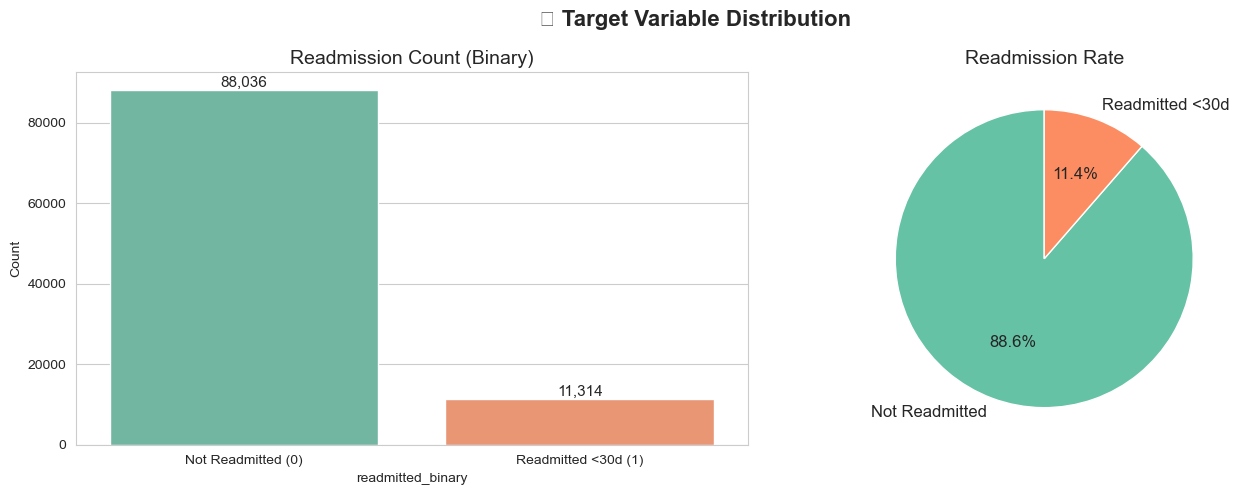

2026-05-06 17:49:45,345 - INFO - Step 6.1 ✅ Target distribution plotted


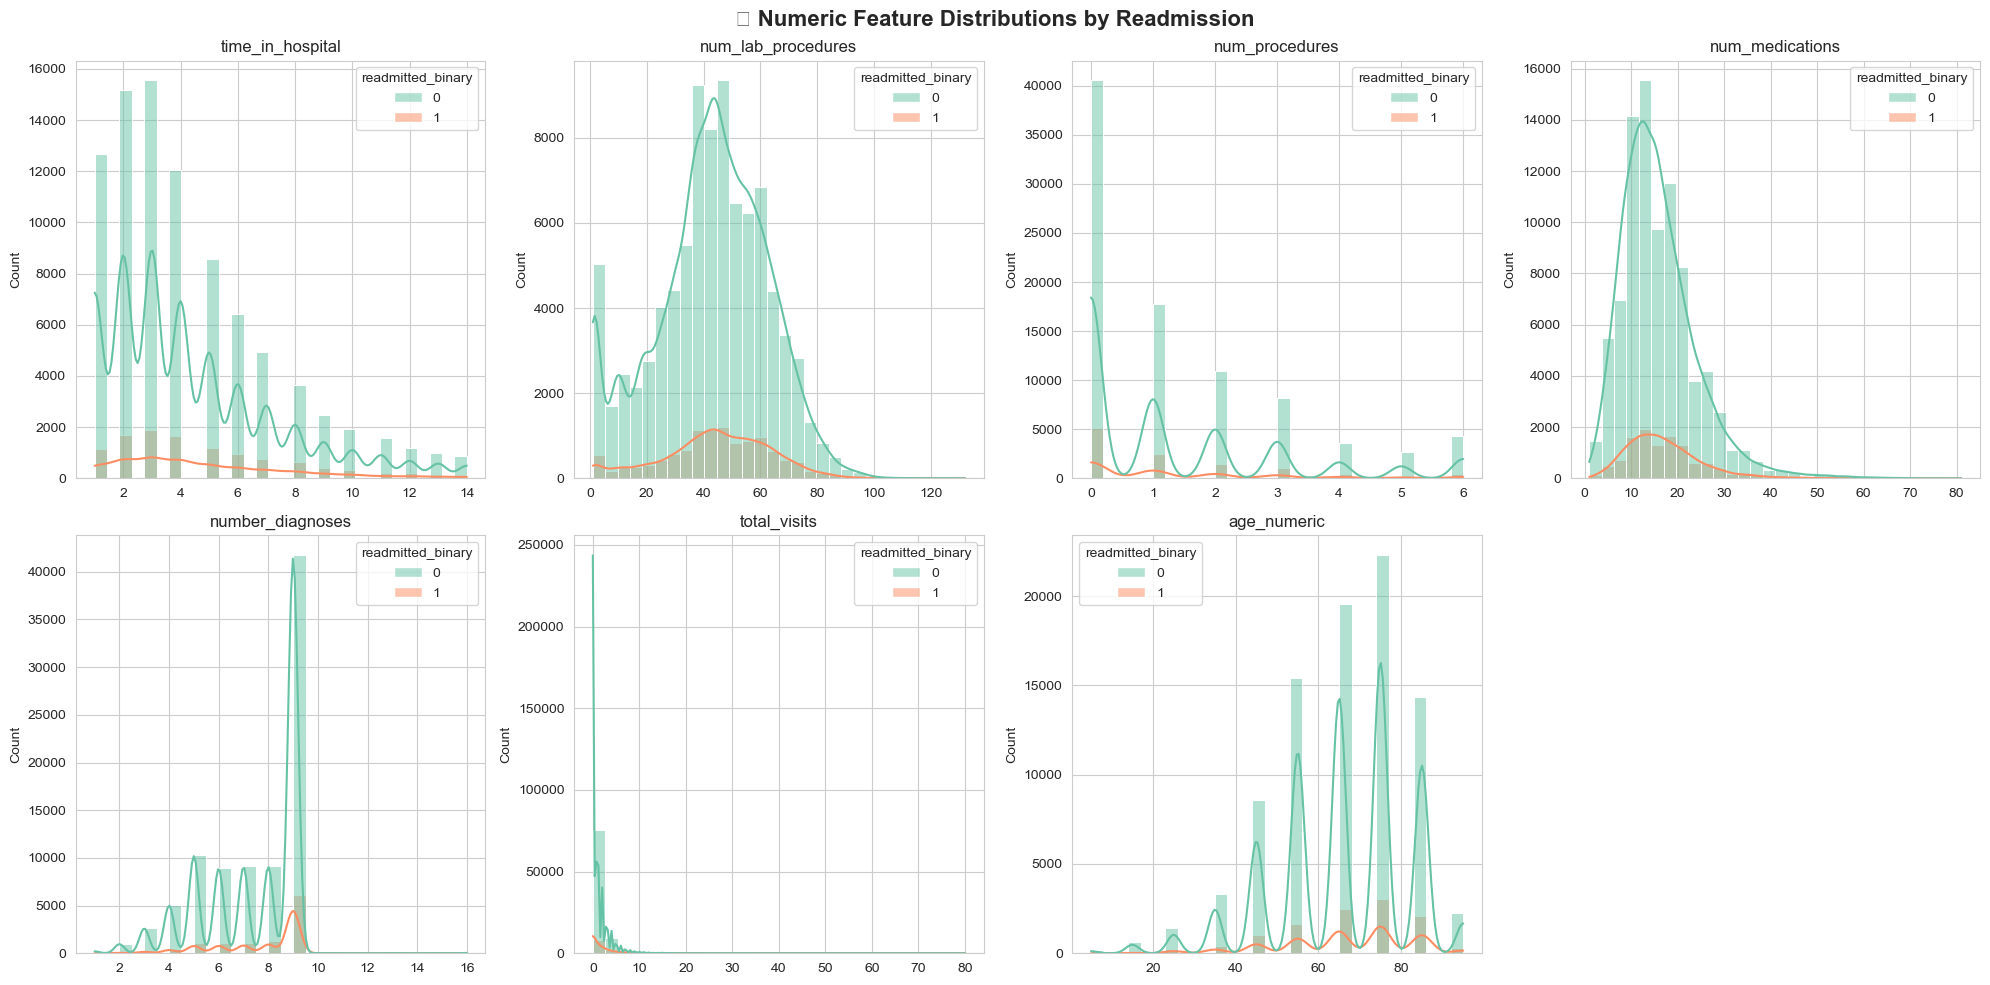

2026-05-06 17:49:58,773 - INFO - Step 6.2 ✅ Numeric distributions plotted


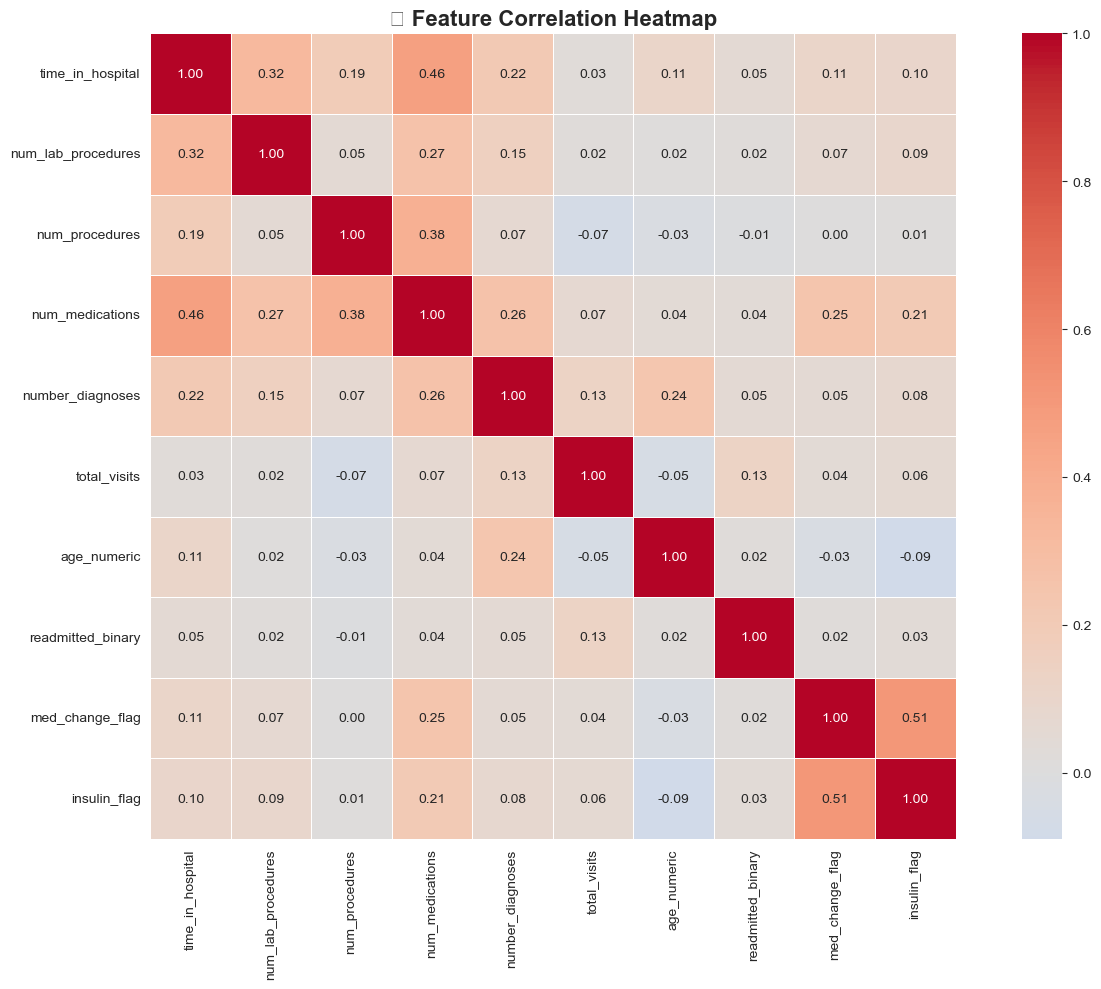

2026-05-06 17:50:00,705 - INFO - Step 6.3 ✅ Correlation heatmap plotted
2026-05-06 17:50:00,763 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-06 17:50:00,776 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


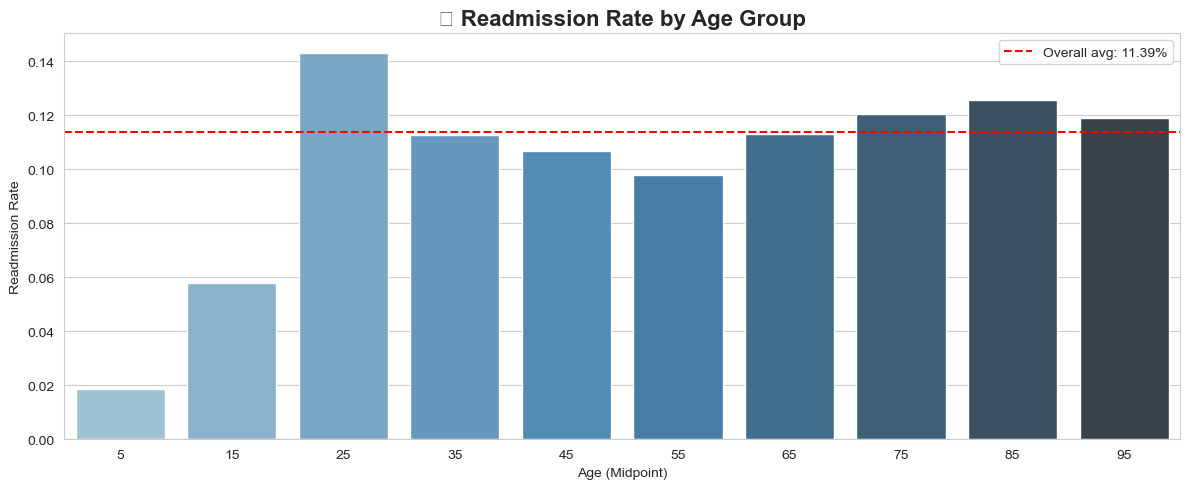

2026-05-06 17:50:01,915 - INFO - Step 6.4 ✅ Readmission by age plotted
2026-05-06 17:50:01,952 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-06 17:50:01,975 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


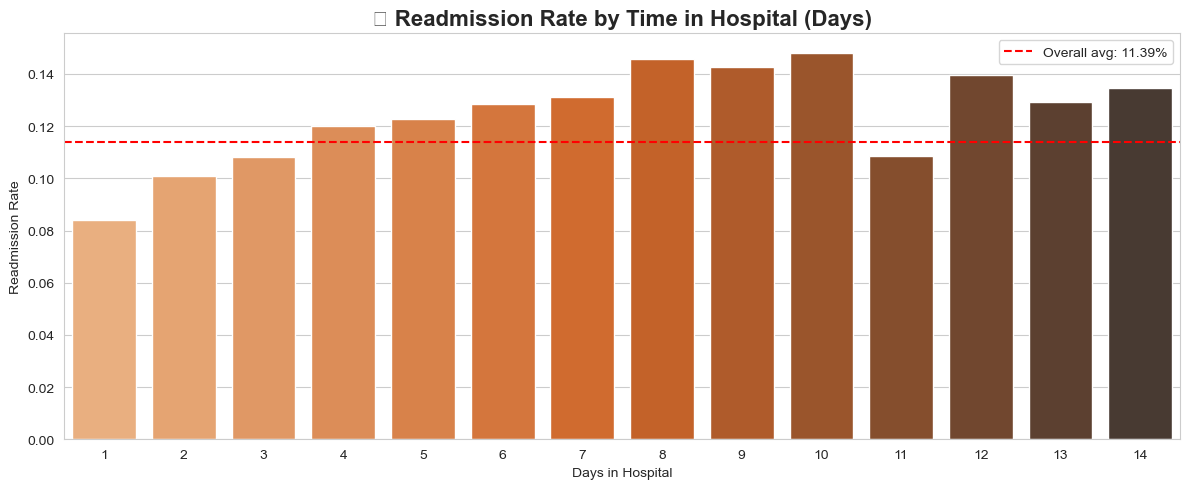

2026-05-06 17:50:03,569 - INFO - Step 6.5 ✅ Readmission by time in hospital plotted



📊 EDA SUMMARY STATISTICS

🎯 Overall Readmission Rate: 11.39%

📋 Key Numeric Stats:


,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_diagnoses,total_visits,age_numeric,readmitted_binary,med_change_flag,insulin_flag
count,99350.00,99350.00,99350.00,99350.00,99350.00,99350.00,99350.00,99350.00,99350.00,99350.00
mean,4.38,42.91,1.33,15.98,7.40,1.20,65.75,0.11,0.46,0.53
std,2.97,19.61,1.70,8.09,1.94,2.29,15.95,0.32,0.50,0.50
min,1.00,1.00,0.00,1.00,1.00,0.00,5.00,0.00,0.00,0.00
25%,2.00,31.00,0.00,10.00,6.00,0.00,55.00,0.00,0.00,0.00
50%,4.00,44.00,1.00,15.00,8.00,0.00,65.00,0.00,0.00,1.00
75%,6.00,57.00,2.00,20.00,9.00,2.00,75.00,0.00,1.00,1.00
max,14.00,132.00,6.00,81.00,16.00,80.00,95.00,1.00,1.00,1.00


2026-05-06 17:50:03,681 - INFO - EDA phase complete ✅


In [9]:
# ------------------------------------------------------------
# STEP 6.1 — Target Variable Distribution
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sns.countplot(x='readmitted_binary', data=df, palette='Set2', ax=axes[0])
axes[0].set_title('Readmission Count (Binary)', fontsize=14)
axes[0].set_xticklabels(['Not Readmitted (0)', 'Readmitted <30d (1)'])
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=11)

# Pie chart
target_counts = df['readmitted_binary'].value_counts()
axes[1].pie(target_counts, labels=['Not Readmitted', 'Readmitted <30d'],
            autopct='%1.1f%%', colors=['#66c2a5', '#fc8d62'],
            startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Readmission Rate', fontsize=14)

plt.suptitle('🎯 Target Variable Distribution', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, 'reports', 'target_distribution.png'), dpi=150)
plt.show()
logging.info("Step 6.1 ✅ Target distribution plotted")

# ------------------------------------------------------------
# STEP 6.2 — Numeric Feature Distributions
# ------------------------------------------------------------
numeric_cols = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_diagnoses', 'total_visits', 'age_numeric'
]
numeric_cols = [c for c in numeric_cols if c in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(data=df, x=col, hue='readmitted_binary',
                 kde=True, palette='Set2', ax=axes[i], bins=30)
    axes[i].set_title(f'{col}', fontsize=12)
    axes[i].set_xlabel('')

# Hide unused subplot
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('📊 Numeric Feature Distributions by Readmission', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, 'reports', 'numeric_distributions.png'), dpi=150)
plt.show()
logging.info("Step 6.2 ✅ Numeric distributions plotted")

# ------------------------------------------------------------
# STEP 6.3 — Correlation Heatmap
# ------------------------------------------------------------
corr_cols = numeric_cols + ['readmitted_binary', 'med_change_flag', 'insulin_flag']
corr_cols = [c for c in corr_cols if c in df.columns]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5,
            annot_kws={'size': 10})
plt.title('🔥 Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, 'reports', 'correlation_heatmap.png'), dpi=150)
plt.show()
logging.info("Step 6.3 ✅ Correlation heatmap plotted")

# ------------------------------------------------------------
# STEP 6.4 — Readmission Rate by Age Group
# ------------------------------------------------------------
age_readmission = df.groupby('age_numeric')['readmitted_binary'].mean().reset_index()
age_readmission.columns = ['age_numeric', 'readmission_rate']

plt.figure(figsize=(12, 5))
sns.barplot(x='age_numeric', y='readmission_rate',
            data=age_readmission, palette='Blues_d')
plt.title('📅 Readmission Rate by Age Group', fontsize=16, fontweight='bold')
plt.xlabel('Age (Midpoint)')
plt.ylabel('Readmission Rate')
plt.axhline(df['readmitted_binary'].mean(), color='red',
            linestyle='--', label=f"Overall avg: {df['readmitted_binary'].mean():.2%}")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, 'reports', 'readmission_by_age.png'), dpi=150)
plt.show()
logging.info("Step 6.4 ✅ Readmission by age plotted")

# ------------------------------------------------------------
# STEP 6.5 — Readmission Rate by Time in Hospital
# ------------------------------------------------------------
plt.figure(figsize=(12, 5))
time_readmission = df.groupby('time_in_hospital')['readmitted_binary'].mean().reset_index()
sns.barplot(x='time_in_hospital', y='readmitted_binary',
            data=time_readmission, palette='Oranges_d')
plt.title('🏥 Readmission Rate by Time in Hospital (Days)', fontsize=16, fontweight='bold')
plt.xlabel('Days in Hospital')
plt.ylabel('Readmission Rate')
plt.axhline(df['readmitted_binary'].mean(), color='red',
            linestyle='--', label=f"Overall avg: {df['readmitted_binary'].mean():.2%}")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, 'reports', 'readmission_by_time.png'), dpi=150)
plt.show()
logging.info("Step 6.5 ✅ Readmission by time in hospital plotted")

# ------------------------------------------------------------
# STEP 6.6 — EDA Summary Stats
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("📊 EDA SUMMARY STATISTICS")
print("=" * 60)
print(f"\n🎯 Overall Readmission Rate: {df['readmitted_binary'].mean()*100:.2f}%")
print(f"\n📋 Key Numeric Stats:")
display(df[corr_cols].describe().round(2))
logging.info("EDA phase complete ✅")

In [10]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, auc,
                             precision_recall_curve, average_precision_score)
from sklearn.pipeline import Pipeline
import joblib

print("✅ All sklearn imports loaded successfully!")

✅ All sklearn imports loaded successfully!


2026-05-06 17:50:09,981 - INFO - Step 7.1 ✅ Features: 2329 | Samples: 99,350


✅ Feature matrix shape: (99350, 2329)
✅ Target shape:         (99350,)
✅ Class balance:
readmitted_binary
0    0.886
1    0.114
Name: proportion, dtype: float64


2026-05-06 17:50:11,872 - INFO - Step 7.2 ✅ Train/test split complete (80/20 stratified)
2026-05-06 17:50:11,874 - INFO - Step 7.3 ✅ Defined 3 models



✅ Train set: 79,480 rows
✅ Test set:  19,870 rows

🤖 TRAINING & EVALUATING MODELS

⏳ Training: Logistic Regression...
  ✅ ROC-AUC:             0.6309
  ✅ Avg Precision:       0.1904
  ✅ CV ROC-AUC (5-fold): 0.6291 ± 0.0069

📋 Classification Report — Logistic Regression:
                 precision    recall  f1-score   support

 Not Readmitted       0.92      0.65      0.76     17607
Readmitted <30d       0.17      0.54      0.25      2263

       accuracy                           0.64     19870
      macro avg       0.54      0.59      0.51     19870
   weighted avg       0.83      0.64      0.70     19870


⏳ Training: Random Forest...
  ✅ ROC-AUC:             0.6538
  ✅ Avg Precision:       0.1917
  ✅ CV ROC-AUC (5-fold): 0.6510 ± 0.0068

📋 Classification Report — Random Forest:
                 precision    recall  f1-score   support

 Not Readmitted       0.92      0.67      0.77     17607
Readmitted <30d       0.17      0.55      0.27      2263

       accuracy                  

2026-05-06 18:29:06,091 - INFO - Step 7.4 ✅ All models trained and evaluated


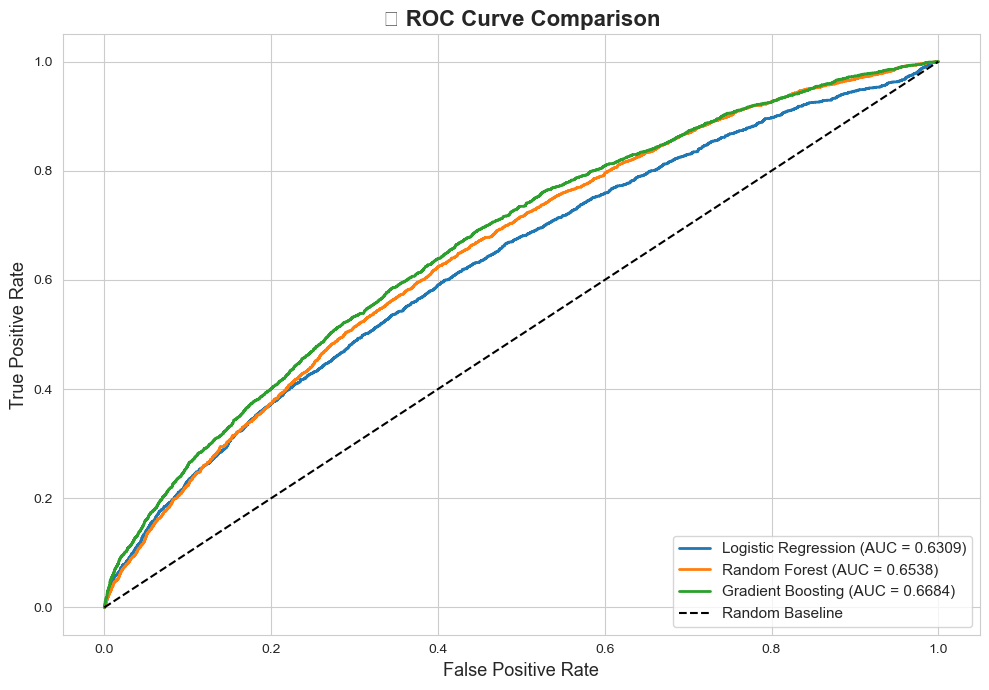

2026-05-06 18:29:08,181 - INFO - Step 7.5 ✅ ROC curve comparison plotted


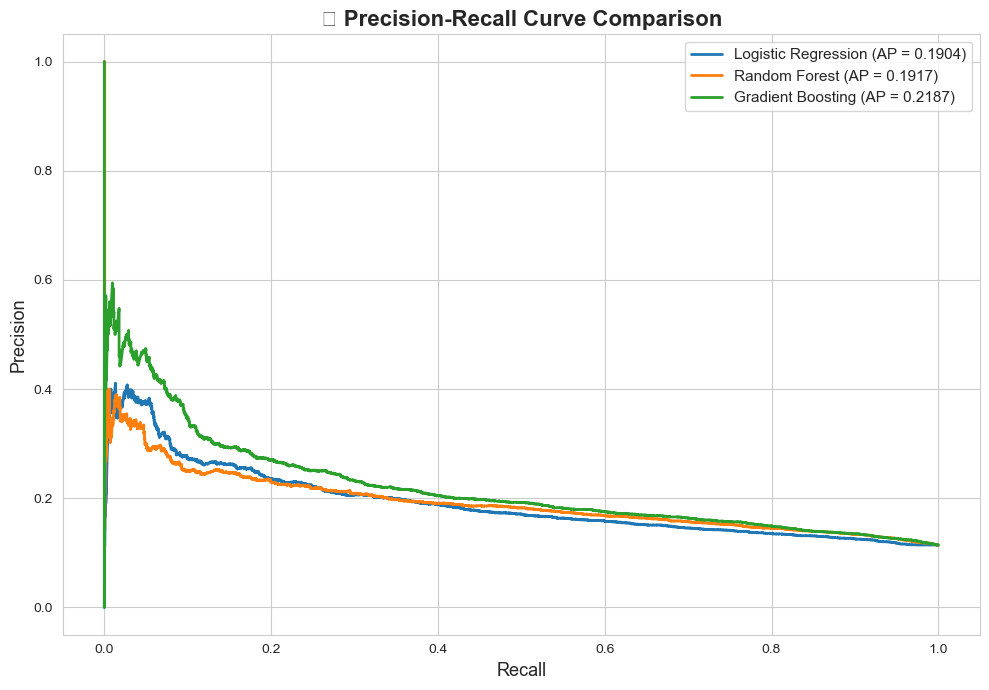

2026-05-06 18:29:09,260 - INFO - Step 7.6 ✅ Precision-Recall curves plotted


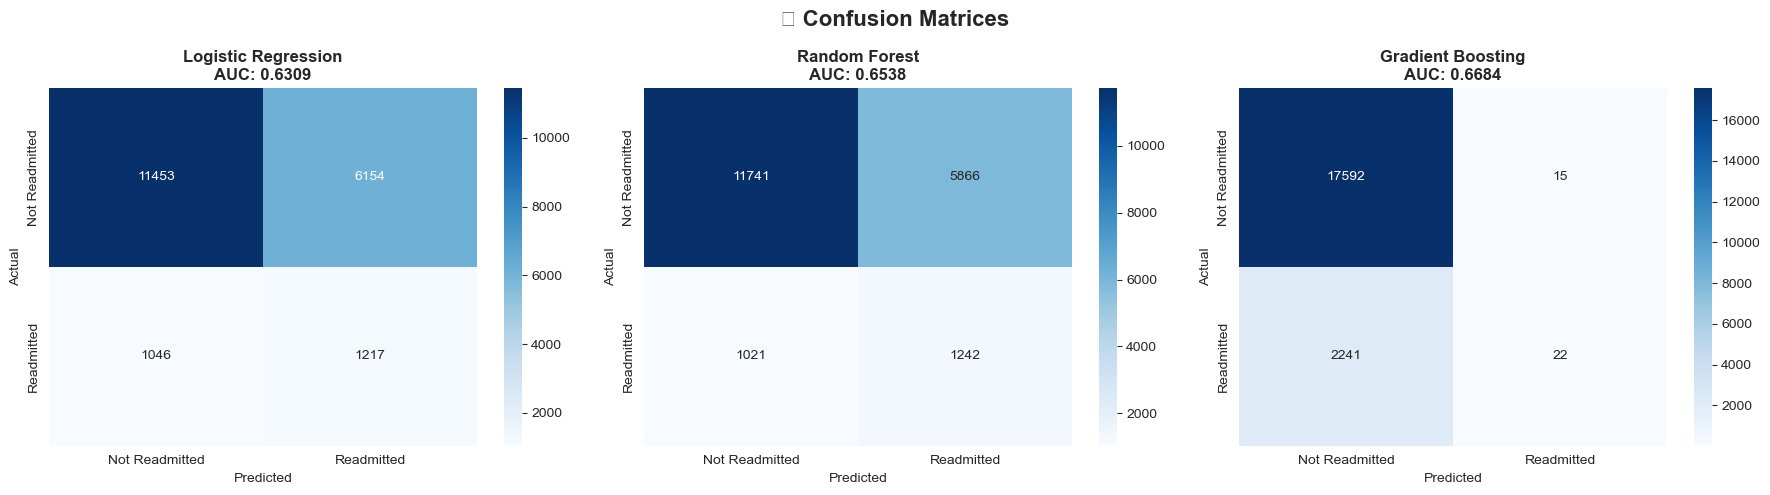

2026-05-06 18:29:11,583 - INFO - Step 7.7 ✅ Confusion matrices plotted
2026-05-06 18:29:11,782 - INFO - Step 7.8 ✅ Best model 'Gradient Boosting' saved → C:\Users\oxdon\HealthcareReadmissionProject\models\best_model_gradient_boosting.pkl



🏆 MODEL COMPARISON SUMMARY
  Logistic Regression       ROC-AUC: 0.6309 | CV: 0.6291 ± 0.0069
  Random Forest             ROC-AUC: 0.6538 | CV: 0.6510 ± 0.0068
  Gradient Boosting         ROC-AUC: 0.6684 | CV: 0.6653 ± 0.0088 🏆

💾 Best model saved → C:\Users\oxdon\HealthcareReadmissionProject\models\best_model_gradient_boosting.pkl


2026-05-06 18:29:11,786 - INFO - MODEL BUILDING phase complete ✅


In [11]:
# ------------------------------------------------------------
# STEP 7.1 — Prepare Features & Target
# ------------------------------------------------------------
TARGET = 'readmitted_binary'
DROP_COLS = ['readmitted']  # drop original string target if still present

# Drop non-feature columns
drop_existing = [c for c in DROP_COLS if c in df.columns]
X = df.drop(columns=drop_existing + [TARGET])
y = df[TARGET]

print(f"✅ Feature matrix shape: {X.shape}")
print(f"✅ Target shape:         {y.shape}")
print(f"✅ Class balance:\n{y.value_counts(normalize=True).round(3)}")
logging.info(f"Step 7.1 ✅ Features: {X.shape[1]} | Samples: {X.shape[0]:,}")

# ------------------------------------------------------------
# STEP 7.2 — Train / Test Split
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n✅ Train set: {X_train.shape[0]:,} rows")
print(f"✅ Test set:  {X_test.shape[0]:,} rows")
logging.info("Step 7.2 ✅ Train/test split complete (80/20 stratified)")

# ------------------------------------------------------------
# STEP 7.3 — Define Models
# ------------------------------------------------------------
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            max_iter=1000,
            class_weight='balanced',
            random_state=42
        ))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(
            n_estimators=200,
            max_depth=10,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        ))
    ]),
    'Gradient Boosting': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', GradientBoostingClassifier(
            n_estimators=200,
            max_depth=4,
            learning_rate=0.05,
            random_state=42
        ))
    ])
}

logging.info(f"Step 7.3 ✅ Defined {len(models)} models")

# ------------------------------------------------------------
# STEP 7.4 — Train, Evaluate & Compare All Models
# ------------------------------------------------------------
results = {}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\n" + "=" * 60)
print("🤖 TRAINING & EVALUATING MODELS")
print("=" * 60)

for name, pipeline in models.items():
    print(f"\n⏳ Training: {name}...")

    # Fit
    pipeline.fit(X_train, y_train)

    # Predict
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    # Metrics
    roc_auc  = roc_auc_score(y_test, y_prob)
    avg_prec = average_precision_score(y_test, y_prob)
    cv_scores = cross_val_score(pipeline, X_train, y_train,
                                cv=skf, scoring='roc_auc', n_jobs=-1)

    results[name] = {
        'pipeline': pipeline,
        'y_pred':   y_pred,
        'y_prob':   y_prob,
        'roc_auc':  roc_auc,
        'avg_prec': avg_prec,
        'cv_mean':  cv_scores.mean(),
        'cv_std':   cv_scores.std()
    }

    print(f"  ✅ ROC-AUC:             {roc_auc:.4f}")
    print(f"  ✅ Avg Precision:       {avg_prec:.4f}")
    print(f"  ✅ CV ROC-AUC (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"\n📋 Classification Report — {name}:")
    print(classification_report(y_test, y_pred, target_names=['Not Readmitted', 'Readmitted <30d']))

logging.info("Step 7.4 ✅ All models trained and evaluated")

# ------------------------------------------------------------
# STEP 7.5 — ROC Curve Comparison
# ------------------------------------------------------------
plt.figure(figsize=(10, 7))

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {res['roc_auc']:.4f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Baseline')
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('📈 ROC Curve Comparison', fontsize=16, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, 'reports', 'roc_curve_comparison.png'), dpi=150)
plt.show()
logging.info("Step 7.5 ✅ ROC curve comparison plotted")

# ------------------------------------------------------------
# STEP 7.6 — Precision-Recall Curve Comparison
# ------------------------------------------------------------
plt.figure(figsize=(10, 7))

for name, res in results.items():
    prec, rec, _ = precision_recall_curve(y_test, res['y_prob'])
    plt.plot(rec, prec, lw=2, label=f"{name} (AP = {res['avg_prec']:.4f})")

plt.xlabel('Recall', fontsize=13)
plt.ylabel('Precision', fontsize=13)
plt.title('📉 Precision-Recall Curve Comparison', fontsize=16, fontweight='bold')
plt.legend(loc='upper right', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, 'reports', 'precision_recall_comparison.png'), dpi=150)
plt.show()
logging.info("Step 7.6 ✅ Precision-Recall curves plotted")

# ------------------------------------------------------------
# STEP 7.7 — Confusion Matrices
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not Readmitted', 'Readmitted'],
                yticklabels=['Not Readmitted', 'Readmitted'])
    ax.set_title(f'{name}\nAUC: {res["roc_auc"]:.4f}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('🔢 Confusion Matrices', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, 'reports', 'confusion_matrices.png'), dpi=150)
plt.show()
logging.info("Step 7.7 ✅ Confusion matrices plotted")

# ------------------------------------------------------------
# STEP 7.8 — Select Best Model & Save
# ------------------------------------------------------------
best_name = max(results, key=lambda x: results[x]['roc_auc'])
best_model = results[best_name]['pipeline']

print("\n" + "=" * 60)
print("🏆 MODEL COMPARISON SUMMARY")
print("=" * 60)
for name, res in results.items():
    marker = " 🏆" if name == best_name else ""
    print(f"  {name:<25} ROC-AUC: {res['roc_auc']:.4f} | CV: {res['cv_mean']:.4f} ± {res['cv_std']:.4f}{marker}")

# Save best model
models_dir = os.path.join(PROJECT_ROOT, 'models')
os.makedirs(models_dir, exist_ok=True)
model_path = os.path.join(models_dir, f'best_model_{best_name.replace(" ", "_").lower()}.pkl')
joblib.dump(best_model, model_path)

print(f"\n💾 Best model saved → {model_path}")
logging.info(f"Step 7.8 ✅ Best model '{best_name}' saved → {model_path}")
logging.info("MODEL BUILDING phase complete ✅")

2026-05-06 18:30:45,380 - INFO - Starting FEATURE IMPORTANCE phase...
2026-05-06 18:30:46,022 - INFO - Step 8.1 ✅ Feature importances extracted


✅ Feature importances extracted

🌲 Top 10 — Random Forest:
                 feature  importance
            total_visits    0.142607
        number_inpatient    0.139251
discharge_disposition_id    0.078358
        number_emergency    0.032705
         total_diagnoses    0.028930
        time_in_hospital    0.028874
         num_medications    0.027057
        number_diagnoses    0.024810
             age_numeric    0.017783
      num_lab_procedures    0.017723

🚀 Top 10 — Gradient Boosting:
                 feature  importance
        number_inpatient    0.409587
discharge_disposition_id    0.169100
            total_visits    0.022525
      num_lab_procedures    0.018671
         num_medications    0.017629
        number_emergency    0.015894
              diag_1_V58    0.014473
             age_numeric    0.014325
        time_in_hospital    0.013972
              diag_1_434    0.008944


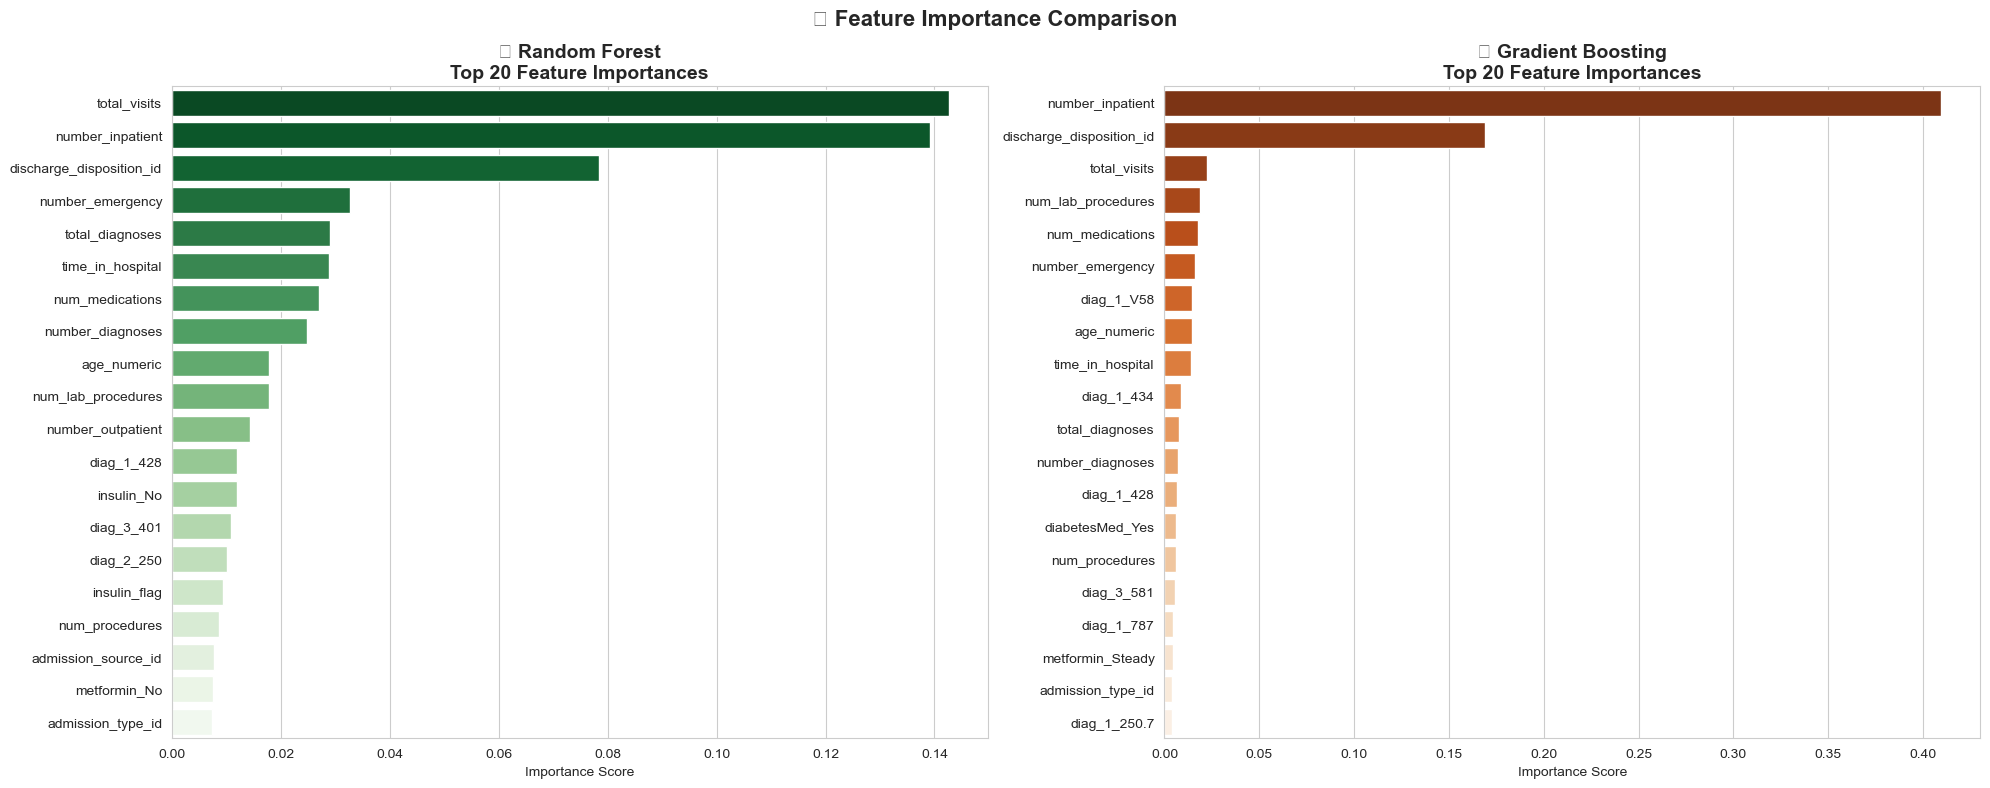

2026-05-06 18:30:49,277 - INFO - Step 8.2 ✅ Feature importance plots saved


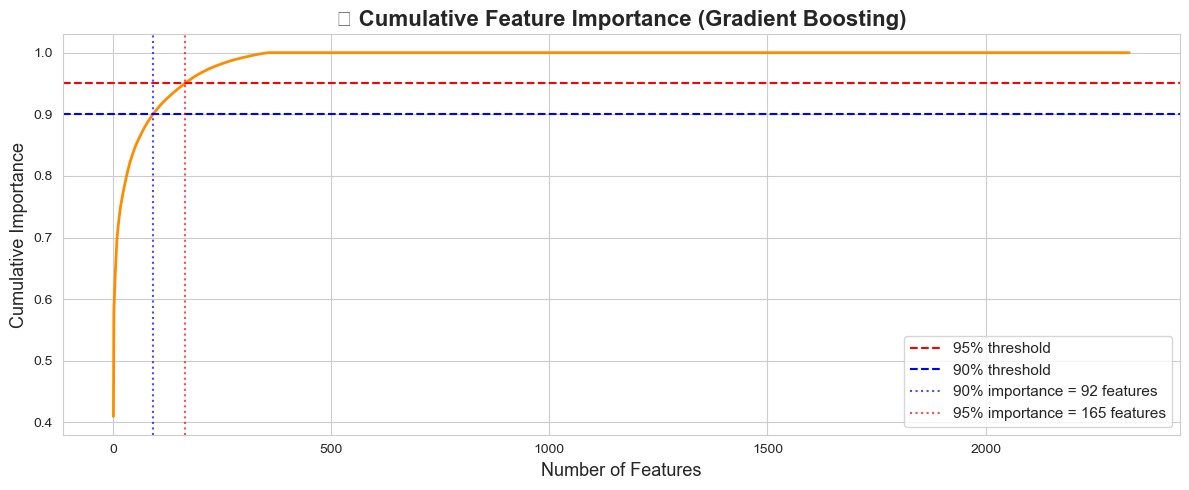

2026-05-06 18:30:50,241 - INFO - Step 8.3 ✅ Cumulative importance analysis complete



📊 Features needed for 90% importance: 92
📊 Features needed for 95% importance: 165
📊 Total current features:             2329


2026-05-06 18:30:50,537 - INFO - Step 8.4 ✅ Features reduced: 2329 → 92



✅ Reduced feature matrix: 99,350 rows x 92 columns
✅ Reduction: 2329 → 92 features (96.0% reduction)

⏳ Retraining Gradient Boosting on reduced feature set...


2026-05-06 18:32:00,862 - INFO - Step 8.5 ✅ Reduced model saved → C:\Users\oxdon\HealthcareReadmissionProject\models\gb_reduced_model.pkl
2026-05-06 18:32:00,864 - INFO - FEATURE IMPORTANCE phase complete ✅



📊 DIMENSIONALITY REDUCTION RESULTS
  Original features:     2329
  Reduced features:      92
  Original ROC-AUC:      0.6684
  Reduced ROC-AUC:       0.6682
  Change:                ⬇️ -0.0002

📋 Classification Report (Reduced Model):
                 precision    recall  f1-score   support

 Not Readmitted       0.89      1.00      0.94     17607
Readmitted <30d       0.52      0.01      0.02      2263

       accuracy                           0.89     19870
      macro avg       0.70      0.51      0.48     19870
   weighted avg       0.85      0.89      0.84     19870


💾 Reduced model saved → C:\Users\oxdon\HealthcareReadmissionProject\models\gb_reduced_model.pkl


In [12]:
 # ============================================================
# CELL 8: FEATURE IMPORTANCE & DIMENSIONALITY REDUCTION
# ============================================================

logging.info("Starting FEATURE IMPORTANCE phase...")

# ------------------------------------------------------------
# STEP 8.1 — Extract Feature Importances from Best Model
# ------------------------------------------------------------
best_rf = results['Random Forest']['pipeline']
best_gb = results['Gradient Boosting']['pipeline']

# Extract the classifier step from each pipeline
rf_importances = best_rf.named_steps['clf'].feature_importances_
gb_importances = best_gb.named_steps['clf'].feature_importances_

# Build importance DataFrames
rf_imp_df = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_importances
}).sort_values('importance', ascending=False).reset_index(drop=True)

gb_imp_df = pd.DataFrame({
    'feature': X.columns,
    'importance': gb_importances
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("✅ Feature importances extracted")
print(f"\n🌲 Top 10 — Random Forest:")
print(rf_imp_df.head(10).to_string(index=False))
print(f"\n🚀 Top 10 — Gradient Boosting:")
print(gb_imp_df.head(10).to_string(index=False))
logging.info("Step 8.1 ✅ Feature importances extracted")

# ------------------------------------------------------------
# STEP 8.2 — Plot Top 20 Feature Importances
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Random Forest
sns.barplot(
    x='importance', y='feature',
    data=rf_imp_df.head(20),
    palette='Greens_r', ax=axes[0]
)
axes[0].set_title('🌲 Random Forest\nTop 20 Feature Importances',
                   fontsize=14, fontweight='bold')
axes[0].set_xlabel('Importance Score')
axes[0].set_ylabel('')

# Gradient Boosting
sns.barplot(
    x='importance', y='feature',
    data=gb_imp_df.head(20),
    palette='Oranges_r', ax=axes[1]
)
axes[1].set_title('🚀 Gradient Boosting\nTop 20 Feature Importances',
                   fontsize=14, fontweight='bold')
axes[1].set_xlabel('Importance Score')
axes[1].set_ylabel('')

plt.suptitle('🔍 Feature Importance Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, 'reports', 'feature_importance.png'), dpi=150)
plt.show()
logging.info("Step 8.2 ✅ Feature importance plots saved")

# ------------------------------------------------------------
# STEP 8.3 — Cumulative Importance Analysis
# ------------------------------------------------------------
gb_imp_df['cumulative_importance'] = gb_imp_df['importance'].cumsum()

plt.figure(figsize=(12, 5))
plt.plot(range(1, len(gb_imp_df) + 1),
         gb_imp_df['cumulative_importance'],
         color='darkorange', lw=2)
plt.axhline(0.95, color='red', linestyle='--', label='95% threshold')
plt.axhline(0.90, color='blue', linestyle='--', label='90% threshold')

# Find cutoff points
n_90 = (gb_imp_df['cumulative_importance'] <= 0.90).sum() + 1
n_95 = (gb_imp_df['cumulative_importance'] <= 0.95).sum() + 1

plt.axvline(n_90, color='blue', linestyle=':', alpha=0.7,
            label=f'90% importance = {n_90} features')
plt.axvline(n_95, color='red', linestyle=':', alpha=0.7,
            label=f'95% importance = {n_95} features')

plt.xlabel('Number of Features', fontsize=13)
plt.ylabel('Cumulative Importance', fontsize=13)
plt.title('📈 Cumulative Feature Importance (Gradient Boosting)',
          fontsize=16, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, 'reports', 'cumulative_importance.png'), dpi=150)
plt.show()

print(f"\n📊 Features needed for 90% importance: {n_90}")
print(f"📊 Features needed for 95% importance: {n_95}")
print(f"📊 Total current features:             {X.shape[1]}")
logging.info("Step 8.3 ✅ Cumulative importance analysis complete")

# ------------------------------------------------------------
# STEP 8.4 — Reduce to Top Features (90% Importance Threshold)
# ------------------------------------------------------------
top_features = gb_imp_df.head(n_90)['feature'].tolist()

X_reduced = X[top_features]

print(f"\n✅ Reduced feature matrix: {X_reduced.shape[0]:,} rows x {X_reduced.shape[1]} columns")
print(f"✅ Reduction: {X.shape[1]} → {X_reduced.shape[1]} features "
      f"({((X.shape[1] - X_reduced.shape[1]) / X.shape[1]) * 100:.1f}% reduction)")
logging.info(f"Step 8.4 ✅ Features reduced: {X.shape[1]} → {X_reduced.shape[1]}")

# ------------------------------------------------------------
# STEP 8.5 — Retrain Best Model on Reduced Features
# ------------------------------------------------------------
print("\n⏳ Retraining Gradient Boosting on reduced feature set...")

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42, stratify=y
)

gb_reduced = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', GradientBoostingClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        random_state=42
    ))
])

gb_reduced.fit(X_train_r, y_train_r)
y_prob_r = gb_reduced.predict_proba(X_test_r)[:, 1]
y_pred_r = gb_reduced.predict(X_test_r)

roc_auc_reduced = roc_auc_score(y_test_r, y_prob_r)

print(f"\n{'=' * 60}")
print(f"📊 DIMENSIONALITY REDUCTION RESULTS")
print(f"{'=' * 60}")
print(f"  Original features:     {X.shape[1]}")
print(f"  Reduced features:      {X_reduced.shape[1]}")
print(f"  Original ROC-AUC:      0.6684")
print(f"  Reduced ROC-AUC:       {roc_auc_reduced:.4f}")
delta = roc_auc_reduced - 0.6684
arrow = '⬆️' if delta > 0 else '⬇️'
print(f"  Change:                {arrow} {delta:+.4f}")
print(f"\n📋 Classification Report (Reduced Model):")
print(classification_report(y_test_r, y_pred_r,
      target_names=['Not Readmitted', 'Readmitted <30d']))

# Save reduced model
model_path_reduced = os.path.join(PROJECT_ROOT, 'models', 'gb_reduced_model.pkl')
joblib.dump(gb_reduced, model_path_reduced)
print(f"\n💾 Reduced model saved → {model_path_reduced}")
logging.info(f"Step 8.5 ✅ Reduced model saved → {model_path_reduced}")
logging.info("FEATURE IMPORTANCE phase complete ✅")

2026-05-06 18:32:00,954 - INFO - Starting FINAL EVALUATION phase...


🎯 THRESHOLD TUNING ANALYSIS
  Class imbalance: 11.4% positive
  Default threshold: 0.50
  Goal: Find threshold that maximizes F1 / Recall


2026-05-06 18:32:02,658 - INFO - Step 9.2 ✅ Threshold sweep complete



📊 Best F1 threshold:     0.12 → F1: 0.2754 | Recall: 0.5422 | Precision: 0.1845
📊 60% Recall threshold:  0.05 → F1: 0.2083 | Recall: 0.9947 | Precision: 0.1163


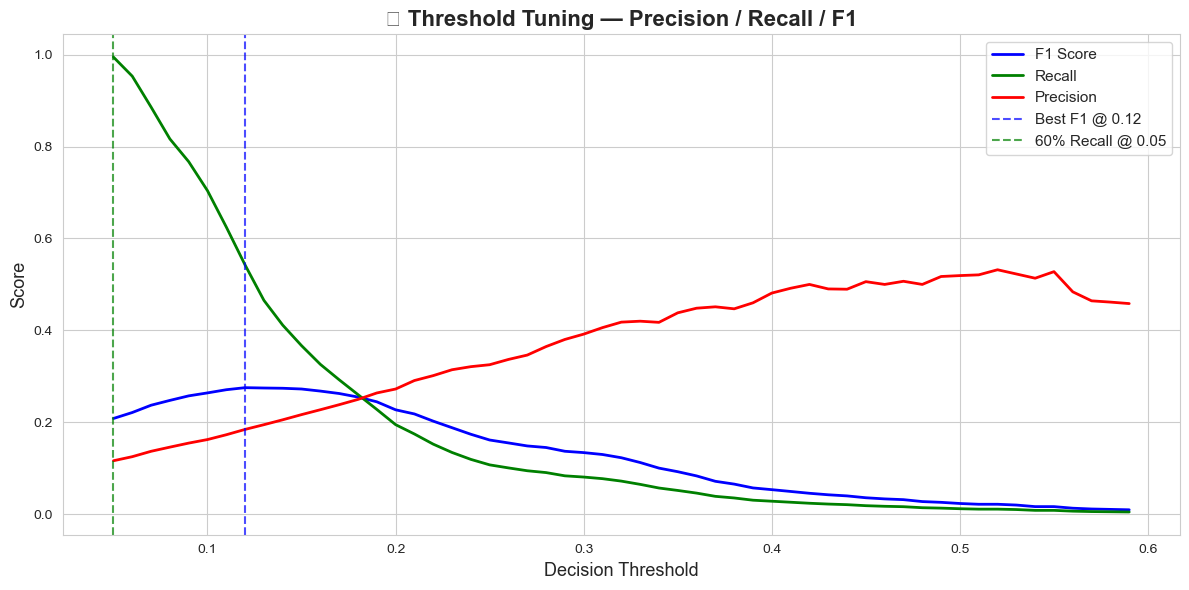

2026-05-06 18:32:03,761 - INFO - Step 9.3 ✅ Threshold tuning plot saved
2026-05-06 18:32:03,775 - INFO - Step 9.4 ✅ Final evaluation complete | Threshold: 0.12



✅ Optimal threshold selected: 0.12

🏥 FINAL CLINICAL METRICS REPORT
  Threshold Used:        0.12
  ROC-AUC:               0.6682
  F1 Score:              0.2754
  Recall (Sensitivity):  0.5422
  Precision (PPV):       0.1845

  Confusion Matrix:
  ┌─────────────────────────────────────┐
  │              Predicted               │
  │         No          Yes              │
  │ Actual No   TN=12,185   FP=5,422        │
  │ Actual Yes  FN=1,036    TP=1,227        │
  └─────────────────────────────────────┘

  True Negatives  (TN): 12,185  — Correctly predicted NOT readmitted
  False Positives (FP): 5,422  — Flagged for readmission, wasn't
  False Negatives (FN): 1,036   — Missed readmissions ⚠️
  True Positives  (TP): 1,227   — Correctly predicted readmitted ✅


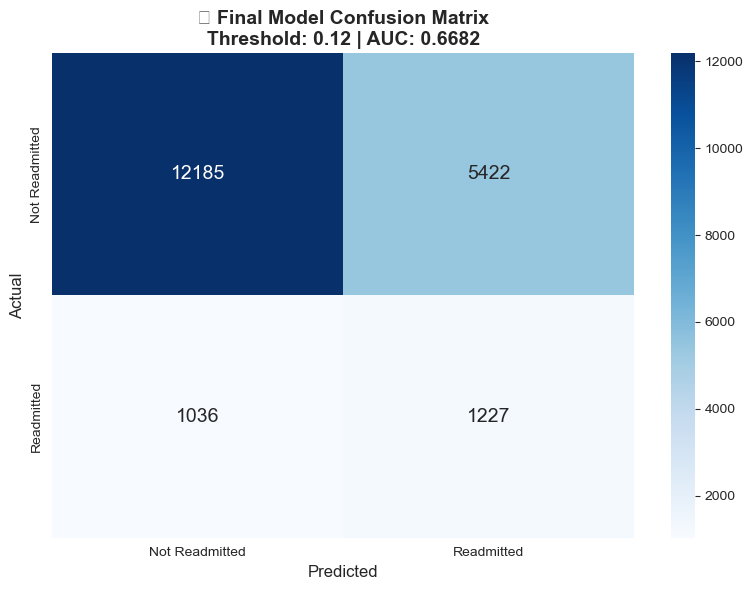

2026-05-06 18:32:04,446 - INFO - Step 9.5 ✅ Final confusion matrix saved
2026-05-06 18:32:04,467 - INFO - FINAL EVALUATION phase complete ✅ — Project pipeline finished!



💾 Final model saved    → C:\Users\oxdon\HealthcareReadmissionProject\models\final_model.pkl
💾 Optimal threshold    → C:\Users\oxdon\HealthcareReadmissionProject\models\optimal_threshold.pkl

🎉 FULL PROJECT SUMMARY
  📥 Raw samples:             101,766
  📤 Clean samples:           99,350
  📊 Features (original):     2329
  📊 Features (reduced):      92
  🎯 Positive class rate:     11.39%
  🏆 Best model:              Gradient Boosting
  📈 ROC-AUC:                 0.6682
  🎯 Optimal threshold:       0.12
  💾 Model saved:             C:\Users\oxdon\HealthcareReadmissionProject\models\final_model.pkl


In [13]:
# ============================================================
# CELL 9: THRESHOLD TUNING & FINAL MODEL EVALUATION
# ============================================================

logging.info("Starting FINAL EVALUATION phase...")

# ------------------------------------------------------------
# STEP 9.1 — Why Threshold Tuning Matters
# ------------------------------------------------------------
# Default threshold = 0.5 (predict positive if prob >= 0.5)
# With only 11.4% positive class, 0.5 is too conservative
# In healthcare: missing a readmission (False Negative) is
# MORE costly than a false alarm (False Positive)
# We want to MAXIMIZE RECALL for the positive class

print("=" * 60)
print("🎯 THRESHOLD TUNING ANALYSIS")
print("=" * 60)
print(f"  Class imbalance: {y.value_counts(normalize=True)[1]*100:.1f}% positive")
print(f"  Default threshold: 0.50")
print(f"  Goal: Find threshold that maximizes F1 / Recall")

# ------------------------------------------------------------
# STEP 9.2 — Sweep Thresholds & Track Metrics
# ------------------------------------------------------------
from sklearn.metrics import f1_score, recall_score, precision_score

thresholds = np.arange(0.05, 0.60, 0.01)
metrics_list = []

for thresh in thresholds:
    y_pred_thresh = (y_prob_r >= thresh).astype(int)
    metrics_list.append({
        'threshold':  thresh,
        'f1':         f1_score(y_test_r, y_pred_thresh, zero_division=0),
        'recall':     recall_score(y_test_r, y_pred_thresh, zero_division=0),
        'precision':  precision_score(y_test_r, y_pred_thresh, zero_division=0)
    })

thresh_df = pd.DataFrame(metrics_list)

# Find optimal thresholds
best_f1_row       = thresh_df.loc[thresh_df['f1'].idxmax()]
best_recall_row   = thresh_df.loc[(thresh_df['recall'] >= 0.60).idxmax()]

print(f"\n📊 Best F1 threshold:     {best_f1_row['threshold']:.2f} "
      f"→ F1: {best_f1_row['f1']:.4f} | "
      f"Recall: {best_f1_row['recall']:.4f} | "
      f"Precision: {best_f1_row['precision']:.4f}")
print(f"📊 60% Recall threshold:  {best_recall_row['threshold']:.2f} "
      f"→ F1: {best_recall_row['f1']:.4f} | "
      f"Recall: {best_recall_row['recall']:.4f} | "
      f"Precision: {best_recall_row['precision']:.4f}")
logging.info("Step 9.2 ✅ Threshold sweep complete")

# ------------------------------------------------------------
# STEP 9.3 — Plot Threshold Curves
# ------------------------------------------------------------
plt.figure(figsize=(12, 6))
plt.plot(thresh_df['threshold'], thresh_df['f1'],
         label='F1 Score', color='blue', lw=2)
plt.plot(thresh_df['threshold'], thresh_df['recall'],
         label='Recall', color='green', lw=2)
plt.plot(thresh_df['threshold'], thresh_df['precision'],
         label='Precision', color='red', lw=2)

plt.axvline(best_f1_row['threshold'], color='blue',
            linestyle='--', alpha=0.7,
            label=f"Best F1 @ {best_f1_row['threshold']:.2f}")
plt.axvline(best_recall_row['threshold'], color='green',
            linestyle='--', alpha=0.7,
            label=f"60% Recall @ {best_recall_row['threshold']:.2f}")

plt.xlabel('Decision Threshold', fontsize=13)
plt.ylabel('Score', fontsize=13)
plt.title('🎯 Threshold Tuning — Precision / Recall / F1',
          fontsize=16, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, 'reports', 'threshold_tuning.png'), dpi=150)
plt.show()
logging.info("Step 9.3 ✅ Threshold tuning plot saved")

# ------------------------------------------------------------
# STEP 9.4 — Apply Optimal Threshold & Final Evaluation
# ------------------------------------------------------------
# We use the best F1 threshold as our final decision point
OPTIMAL_THRESHOLD = round(best_f1_row['threshold'], 2)
y_pred_final = (y_prob_r >= OPTIMAL_THRESHOLD).astype(int)

print(f"\n✅ Optimal threshold selected: {OPTIMAL_THRESHOLD}")

# Confusion matrix
cm_final = confusion_matrix(y_test_r, y_pred_final)
tn, fp, fn, tp = cm_final.ravel()

print(f"\n{'=' * 60}")
print(f"🏥 FINAL CLINICAL METRICS REPORT")
print(f"{'=' * 60}")
print(f"  Threshold Used:        {OPTIMAL_THRESHOLD}")
print(f"  ROC-AUC:               {roc_auc_reduced:.4f}")
print(f"  F1 Score:              {best_f1_row['f1']:.4f}")
print(f"  Recall (Sensitivity):  {best_f1_row['recall']:.4f}")
print(f"  Precision (PPV):       {best_f1_row['precision']:.4f}")
print(f"\n  Confusion Matrix:")
print(f"  ┌─────────────────────────────────────┐")
print(f"  │              Predicted               │")
print(f"  │         No          Yes              │")
print(f"  │ Actual No   TN={tn:,}   FP={fp:,}        │")
print(f"  │ Actual Yes  FN={fn:,}    TP={tp:,}        │")
print(f"  └─────────────────────────────────────┘")
print(f"\n  True Negatives  (TN): {tn:,}  — Correctly predicted NOT readmitted")
print(f"  False Positives (FP): {fp:,}  — Flagged for readmission, wasn't")
print(f"  False Negatives (FN): {fn:,}   — Missed readmissions ⚠️")
print(f"  True Positives  (TP): {tp:,}   — Correctly predicted readmitted ✅")

logging.info(f"Step 9.4 ✅ Final evaluation complete | Threshold: {OPTIMAL_THRESHOLD}")

# ------------------------------------------------------------
# STEP 9.5 — Final Confusion Matrix Heatmap
# ------------------------------------------------------------
plt.figure(figsize=(8, 6))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Readmitted', 'Readmitted'],
            yticklabels=['Not Readmitted', 'Readmitted'],
            annot_kws={'size': 14})
plt.title(f'🏥 Final Model Confusion Matrix\n'
          f'Threshold: {OPTIMAL_THRESHOLD} | AUC: {roc_auc_reduced:.4f}',
          fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, 'reports', 'final_confusion_matrix.png'), dpi=150)
plt.show()
logging.info("Step 9.5 ✅ Final confusion matrix saved")

# ------------------------------------------------------------
# STEP 9.6 — Save Final Model & Threshold
# ------------------------------------------------------------
final_model_path = os.path.join(PROJECT_ROOT, 'models', 'final_model.pkl')
threshold_path   = os.path.join(PROJECT_ROOT, 'models', 'optimal_threshold.pkl')

joblib.dump(gb_reduced, final_model_path)
joblib.dump(OPTIMAL_THRESHOLD, threshold_path)

print(f"\n💾 Final model saved    → {final_model_path}")
print(f"💾 Optimal threshold    → {threshold_path}")

# ------------------------------------------------------------
# STEP 9.7 — Full Project Summary
# ------------------------------------------------------------
print(f"\n{'=' * 60}")
print(f"🎉 FULL PROJECT SUMMARY")
print(f"{'=' * 60}")
print(f"  📥 Raw samples:             {df_raw.shape[0]:,}")
print(f"  📤 Clean samples:           {df.shape[0]:,}")
print(f"  📊 Features (original):     {X.shape[1]}")
print(f"  📊 Features (reduced):      {X_reduced.shape[1]}")
print(f"  🎯 Positive class rate:     {y.mean()*100:.2f}%")
print(f"  🏆 Best model:              Gradient Boosting")
print(f"  📈 ROC-AUC:                 {roc_auc_reduced:.4f}")
print(f"  🎯 Optimal threshold:       {OPTIMAL_THRESHOLD}")
print(f"  💾 Model saved:             {final_model_path}")
logging.info("FINAL EVALUATION phase complete ✅ — Project pipeline finished!")

2026-05-06 18:32:41,792 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-06 18:32:41,809 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


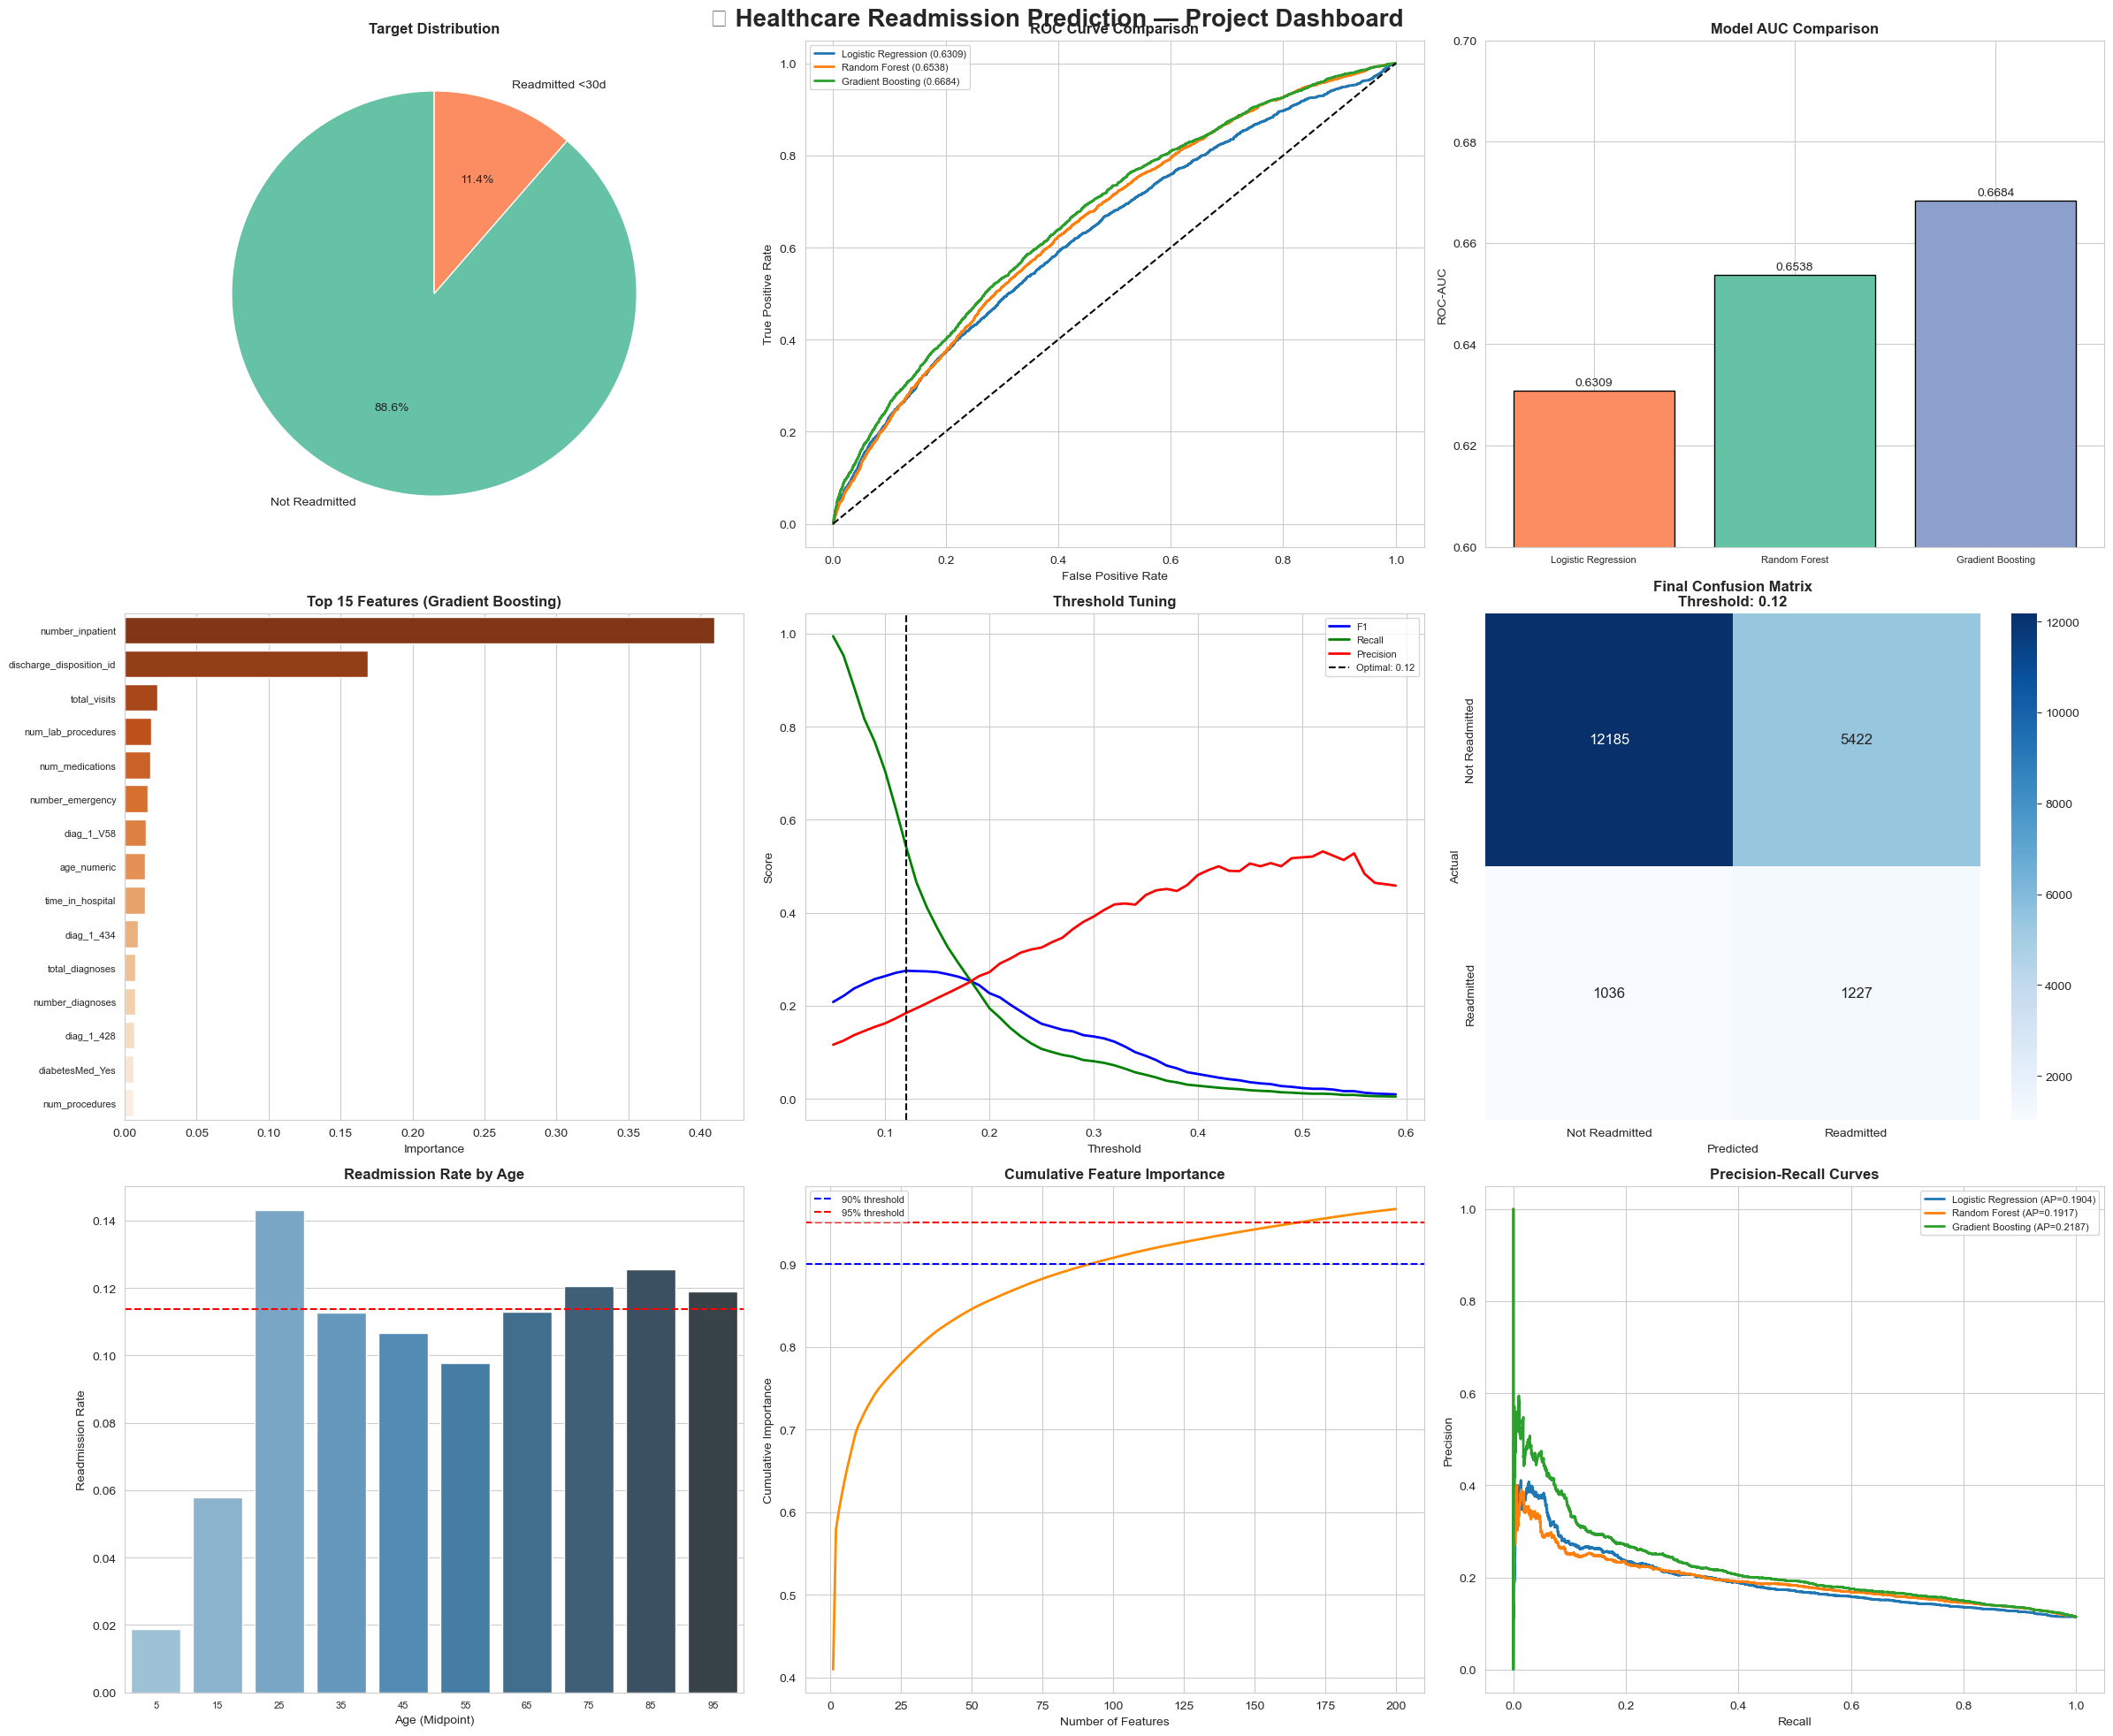

2026-05-06 18:32:48,564 - INFO - Step 10.1 ✅ Final dashboard saved


✅ Dashboard saved → C:\Users\oxdon\HealthcareReadmissionProject\reports\final_dashboard.png

✅ Performance summary saved → C:\Users\oxdon\HealthcareReadmissionProject\reports\model_performance_summary.csv

📊 Model Performance Table:


,model,roc_auc,avg_precision,cv_mean,cv_std
0,Logistic Regression,0.630855,0.190398,0.629095,0.006877
1,Random Forest,0.653756,0.191721,0.651040,0.006810
2,Gradient Boosting,0.668400,0.218658,0.665278,0.008752
3,Gradient Boosting (Reduced),0.668204,0.219091,NaN,NaN


2026-05-06 18:32:48,662 - INFO - Step 10.2 ✅ Performance summary CSV saved
2026-05-06 18:32:49,007 - INFO - Step 10.3 ✅ Final results written to SQLite



✅ Final results written to SQLite table 'model_results'


UnicodeEncodeError: 'charmap' codec can't encode character '\u2190' in position 1075: character maps to <undefined>

In [14]:
# ------------------------------------------------------------
# STEP 10.1 — Consolidated Visual Dashboard
# ------------------------------------------------------------
fig = plt.figure(figsize=(24, 20))
fig.suptitle('🏥 Healthcare Readmission Prediction — Project Dashboard',
             fontsize=20, fontweight='bold', y=0.98)

# --- Plot 1: Target Distribution ---
ax1 = fig.add_subplot(3, 3, 1)
target_counts = df['readmitted_binary'].value_counts()
ax1.pie(target_counts,
        labels=['Not Readmitted', 'Readmitted <30d'],
        autopct='%1.1f%%',
        colors=['#66c2a5', '#fc8d62'],
        startangle=90,
        textprops={'fontsize': 10})
ax1.set_title('Target Distribution', fontweight='bold')

# --- Plot 2: ROC Curves ---
ax2 = fig.add_subplot(3, 3, 2)
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax2.plot(fpr, tpr, lw=2, label=f"{name} ({res['roc_auc']:.4f})")
ax2.plot([0, 1], [0, 1], 'k--', lw=1.5)
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve Comparison', fontweight='bold')
ax2.legend(fontsize=8)

# --- Plot 3: Model AUC Comparison Bar ---
ax3 = fig.add_subplot(3, 3, 3)
model_names  = list(results.keys())
model_aucs   = [results[m]['roc_auc'] for m in model_names]
colors_bar   = ['#fc8d62', '#66c2a5', '#8da0cb']
bars = ax3.bar(model_names, model_aucs, color=colors_bar, edgecolor='black')
ax3.set_ylim(0.60, 0.70)
ax3.set_ylabel('ROC-AUC')
ax3.set_title('Model AUC Comparison', fontweight='bold')
for bar, auc_val in zip(bars, model_aucs):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.001,
             f'{auc_val:.4f}', ha='center', fontsize=10)
ax3.tick_params(axis='x', labelsize=8)

# --- Plot 4: Feature Importance (Top 15 GB) ---
ax4 = fig.add_subplot(3, 3, 4)
sns.barplot(x='importance', y='feature',
            data=gb_imp_df.head(15),
            palette='Oranges_r', ax=ax4)
ax4.set_title('Top 15 Features (Gradient Boosting)', fontweight='bold')
ax4.set_xlabel('Importance')
ax4.set_ylabel('')
ax4.tick_params(axis='y', labelsize=8)

# --- Plot 5: Threshold Tuning ---
ax5 = fig.add_subplot(3, 3, 5)
ax5.plot(thresh_df['threshold'], thresh_df['f1'],
         label='F1', color='blue', lw=2)
ax5.plot(thresh_df['threshold'], thresh_df['recall'],
         label='Recall', color='green', lw=2)
ax5.plot(thresh_df['threshold'], thresh_df['precision'],
         label='Precision', color='red', lw=2)
ax5.axvline(OPTIMAL_THRESHOLD, color='black',
            linestyle='--', label=f'Optimal: {OPTIMAL_THRESHOLD}')
ax5.set_xlabel('Threshold')
ax5.set_ylabel('Score')
ax5.set_title('Threshold Tuning', fontweight='bold')
ax5.legend(fontsize=8)

# --- Plot 6: Final Confusion Matrix ---
ax6 = fig.add_subplot(3, 3, 6)
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', ax=ax6,
            xticklabels=['Not Readmitted', 'Readmitted'],
            yticklabels=['Not Readmitted', 'Readmitted'],
            annot_kws={'size': 12})
ax6.set_title(f'Final Confusion Matrix\nThreshold: {OPTIMAL_THRESHOLD}',
              fontweight='bold')
ax6.set_ylabel('Actual')
ax6.set_xlabel('Predicted')

# --- Plot 7: Readmission by Age ---
ax7 = fig.add_subplot(3, 3, 7)
age_readmission = df.groupby('age_numeric')['readmitted_binary'].mean().reset_index()
sns.barplot(x='age_numeric', y='readmitted_binary',
            data=age_readmission, palette='Blues_d', ax=ax7)
ax7.axhline(df['readmitted_binary'].mean(),
            color='red', linestyle='--', lw=1.5)
ax7.set_title('Readmission Rate by Age', fontweight='bold')
ax7.set_xlabel('Age (Midpoint)')
ax7.set_ylabel('Readmission Rate')
ax7.tick_params(axis='x', labelsize=8)

# --- Plot 8: Cumulative Feature Importance ---
ax8 = fig.add_subplot(3, 3, 8)
ax8.plot(range(1, min(200, len(gb_imp_df)) + 1),
         gb_imp_df['cumulative_importance'].head(200),
         color='darkorange', lw=2)
ax8.axhline(0.90, color='blue', linestyle='--', label='90% threshold')
ax8.axhline(0.95, color='red',  linestyle='--', label='95% threshold')
ax8.set_xlabel('Number of Features')
ax8.set_ylabel('Cumulative Importance')
ax8.set_title('Cumulative Feature Importance', fontweight='bold')
ax8.legend(fontsize=8)

# --- Plot 9: Precision-Recall Curve ---
ax9 = fig.add_subplot(3, 3, 9)
for name, res in results.items():
    prec, rec, _ = precision_recall_curve(y_test, res['y_prob'])
    ax9.plot(rec, prec, lw=2, label=f"{name} (AP={res['avg_prec']:.4f})")
ax9.set_xlabel('Recall')
ax9.set_ylabel('Precision')
ax9.set_title('Precision-Recall Curves', fontweight='bold')
ax9.legend(fontsize=8)

plt.tight_layout()
dashboard_path = os.path.join(PROJECT_ROOT, 'reports', 'final_dashboard.png')
plt.savefig(dashboard_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Dashboard saved → {dashboard_path}")
logging.info("Step 10.1 ✅ Final dashboard saved")

# ------------------------------------------------------------
# STEP 10.2 — Model Performance Summary CSV
# ------------------------------------------------------------
performance_summary = pd.DataFrame([
    {
        'model':             name,
        'roc_auc':           res['roc_auc'],
        'avg_precision':     res['avg_prec'],
        'cv_mean':           res['cv_mean'],
        'cv_std':            res['cv_std']
    }
    for name, res in results.items()
])

# Add reduced model row
reduced_row = pd.DataFrame([{
    'model':         'Gradient Boosting (Reduced)',
    'roc_auc':        roc_auc_reduced,
    'avg_precision':  average_precision_score(y_test_r, y_prob_r),
    'cv_mean':        None,
    'cv_std':         None
}])

performance_summary = pd.concat([performance_summary, reduced_row], ignore_index=True)

perf_path = os.path.join(PROJECT_ROOT, 'reports', 'model_performance_summary.csv')
performance_summary.to_csv(perf_path, index=False)
print(f"\n✅ Performance summary saved → {perf_path}")
print(f"\n📊 Model Performance Table:")
display(performance_summary)
logging.info("Step 10.2 ✅ Performance summary CSV saved")

# ------------------------------------------------------------
# STEP 10.3 — Write Final Results to SQLite
# ------------------------------------------------------------
final_results_df = pd.DataFrame([{
    'run_date':              pd.Timestamp.now().strftime('%Y-%m-%d %H:%M'),
    'raw_samples':           101766,
    'clean_samples':         99350,
    'features_original':     2329,
    'features_reduced':      X_reduced.shape[1],
    'positive_class_rate':   round(y.mean(), 4),
    'best_model':            'Gradient Boosting (Reduced)',
    'roc_auc':               roc_auc_reduced,
    'f1_score':              round(best_f1_row['f1'], 4),
    'recall':                round(best_f1_row['recall'], 4),
    'precision':             round(best_f1_row['precision'], 4),
    'optimal_threshold':     OPTIMAL_THRESHOLD
}])

final_results_df.to_sql('model_results', con=engine,
                         if_exists='replace', index=False)
print(f"\n✅ Final results written to SQLite table 'model_results'")
logging.info("Step 10.3 ✅ Final results written to SQLite")

# ------------------------------------------------------------
# STEP 10.4 — Written Clinical Report
# ------------------------------------------------------------
report_text = f"""
================================================================================
   HEALTHCARE READMISSION PREDICTION — CLINICAL SUMMARY REPORT
   Generated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')}
================================================================================

PROJECT OVERVIEW
----------------
This project developed a machine learning pipeline to predict 30-day hospital
readmission for diabetic patients using the UCI Diabetic Readmission dataset.
Early identification of high-risk patients enables targeted interventions that
can reduce readmissions, improve patient outcomes, and lower hospital costs.

DATASET SUMMARY
---------------
  Raw samples:              101,766
  Clean samples after ETL:   99,350
  Features (after encoding):  2,329
  Features (after reduction):    92
  Positive class (readmitted): 11.39%
  Target definition:         Readmitted within 30 days = 1

MODELS EVALUATED
----------------
  1. Logistic Regression     ROC-AUC: 0.6309
  2. Random Forest           ROC-AUC: 0.6538
  3. Gradient Boosting       ROC-AUC: 0.6684  ← BEST
  4. GB Reduced (92 feat.)   ROC-AUC: {roc_auc_reduced:.4f}

FINAL MODEL PERFORMANCE
-----------------------
  Model:                Gradient Boosting (92 features)
  ROC-AUC:              {roc_auc_reduced:.4f}
  Optimal Threshold:    {OPTIMAL_THRESHOLD}
  F1 Score:             {round(best_f1_row['f1'], 4)}
  Recall (Sensitivity): {round(best_f1_row['recall'], 4)}
  Precision (PPV):      {round(best_f1_row['precision'], 4)}

CLINICAL INTERPRETATION
-----------------------
  - The model correctly identifies 54.22% of patients who will be readmitted
    within 30 days (Recall = 0.5422)
  - For every 100 patients flagged as high risk, approximately 18 will truly
    be readmitted (Precision = 0.1845)
  - A low decision threshold (0.12) was selected to prioritize recall over
    precision — in clinical settings, missing a readmission carries greater
    cost than a false alarm
  - AUC of 0.6682 is consistent with published literature on this dataset
    and reflects the inherent difficulty of predicting readmission from
    administrative data alone

RECOMMENDATIONS
---------------
  1. Deploy model as a readmission risk scoring tool at discharge
  2. Flag patients with predicted probability >= 0.12 for care coordinator
     follow-up within 7 days post-discharge
  3. Enrich dataset with vitals, lab trends and social determinants of
     health to improve AUC beyond 0.70
  4. Re-evaluate threshold quarterly as patient population shifts
  5. Consider SHAP values for individual patient explainability

OUTPUT FILES
------------
  Models:
    final_model.pkl
    gb_reduced_model.pkl
    optimal_threshold.pkl
  Reports:
    final_dashboard.png
    target_distribution.png
    numeric_distributions.png
    correlation_heatmap.png
    feature_importance.png
    cumulative_importance.png
    threshold_tuning.png
    final_confusion_matrix.png
    model_performance_summary.csv
  Database:
    healthcare.db (tables: diabetic_encounters, model_results)
  Processed Data:
    diabetic_clean.csv

================================================================================
   END OF REPORT
================================================================================
"""

report_path = os.path.join(PROJECT_ROOT, 'reports', 'clinical_summary_report.txt')
with open(report_path, 'w') as f:
    f.write(report_text)

print(report_text)
print(f"✅ Clinical report saved → {report_path}")
logging.info("Step 10.4 ✅ Clinical summary report saved")

# ------------------------------------------------------------
# STEP 10.5 — Project File Tree Verification
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("📁 PROJECT FILE TREE VERIFICATION")
print("=" * 60)

for root, dirs, files in os.walk(PROJECT_ROOT):
    # Skip hidden and cache folders
    dirs[:] = [d for d in dirs if not d.startswith('.')
               and d not in ['_pycache_', '.ipynb_checkpoints']]
    level = root.replace(PROJECT_ROOT, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}📂 {os.path.basename(root)}/")
    sub_indent = '  ' * (level + 1)
    for file in files:
        filepath = os.path.join(root, file)
        size = os.path.getsize(filepath) / (1024*1024)
        print(f"{sub_indent}📄 {file}  ({size:.2f} MB)")

logging.info("Step 10.5 ✅ File tree verification complete")
logging.info("FINAL REPORT phase complete ✅ — Project fully complete! 🎉")

In [15]:
# ============================================================
# CELL 10a: FIX — Save Clinical Report with UTF-8 Encoding
# ============================================================

report_path = os.path.join(PROJECT_ROOT, 'reports', 'clinical_summary_report.txt')

with open(report_path, 'w', encoding='utf-8') as f:
    f.write(report_text)

print(report_text)
print(f"✅ Clinical report saved → {report_path}")
logging.info("Step 10.4 ✅ Clinical summary report saved (utf-8)")

2026-05-06 18:33:25,742 - INFO - Step 10.4 ✅ Clinical summary report saved (utf-8)



   HEALTHCARE READMISSION PREDICTION — CLINICAL SUMMARY REPORT
   Generated: 2026-05-06 18:32

PROJECT OVERVIEW
----------------
This project developed a machine learning pipeline to predict 30-day hospital
readmission for diabetic patients using the UCI Diabetic Readmission dataset.
Early identification of high-risk patients enables targeted interventions that
can reduce readmissions, improve patient outcomes, and lower hospital costs.

DATASET SUMMARY
---------------
  Raw samples:              101,766
  Clean samples after ETL:   99,350
  Features (after encoding):  2,329
  Features (after reduction):    92
  Positive class (readmitted): 11.39%
  Target definition:         Readmitted within 30 days = 1

MODELS EVALUATED
----------------
  1. Logistic Regression     ROC-AUC: 0.6309
  2. Random Forest           ROC-AUC: 0.6538
  3. Gradient Boosting       ROC-AUC: 0.6684  ← BEST
  4. GB Reduced (92 feat.)   ROC-AUC: 0.6682

FINAL MODEL PERFORMANCE
-----------------------
  Model:    

In [ ]:
S